In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install wandb

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import wandb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

paths = {
    "NURBS": (
        "/content/drive/MyDrive/LDC_data/nurbs_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC_data/nurbs_lid_driven_cavity_Y.npz"
    ),
    "Harmonics": (
        "/content/drive/MyDrive/LDC_data/harmonics_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC_data/harmonics_lid_driven_cavity_Y.npz"
    ),
    "Skelneton": (
        "/content/drive/MyDrive/LDC_data/skelneton_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC_data/skelneton_lid_driven_cavity_Y.npz"
    )
}

Mounted at /content/drive
Using device: cuda


In [ ]:
class Normalizer:
    """Z-score normalizer — fitted on training data only."""
    def __init__(self, data, eps=1e-8):
        # data: [N, C, H, W] or [N, C, HW]
        self.mean = data.mean(dim=0, keepdim=True)
        self.std  = data.std(dim=0, keepdim=True).clamp(min=eps)

    def encode(self, x):
        return (x - self.mean.to(x.device)) / self.std.to(x.device)

    def decode(self, x):
        return x * self.std.to(x.device) + self.mean.to(x.device)


def relative_l2(pred, true):
    """Global relative L2 error."""
    return torch.norm(pred - true) / (torch.norm(true) + 1e-8)

In [ ]:
class SpectralConv2d(nn.Module):
    """
    2D Fourier integral operator layer (core of FNO).
    Keeps only the lowest `modes` Fourier frequencies in each spatial dimension,
    applies a learned complex-valued weight in frequency space,
    then transforms back via iFFT.

    Forward pass:
        x -> FFT2 -> truncate to (modes x modes) -> multiply by W -> iFFT2
           + pointwise linear bypass (R)
    """
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1       = modes1   # Fourier modes along H
        self.modes2       = modes2   # Fourier modes along W

        # Scaling factor from original FNO paper
        scale = 1 / (in_channels * out_channels)

        # Complex weights for the 4 quadrants of the truncated FFT
        # Shape: [in_channels, out_channels, modes1, modes2]
        self.weights1 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2,
                               dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2,
                               dtype=torch.cfloat)
        )

    def compl_mul2d(self, inp, weights):
        """
        Complex multiplication:
        inp:     [B, in_channels,  modes1, modes2]
        weights: [in_channels, out_channels, modes1, modes2]
        output:  [B, out_channels, modes1, modes2]
        """
        return torch.einsum("bixy,ioxy->boxy", inp, weights)

    def forward(self, x):
        B, C, H, W = x.shape

        # ── FFT along spatial dims ────────────────────────────────────────────
        x_ft = torch.fft.rfft2(x)   # [B, C, H, W//2+1]

        # ── Allocate output in frequency domain ───────────────────────────────
        out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)

        # Lower-left  Fourier block
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        # Upper-left Fourier block (negative frequencies along H)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )

        # ── Inverse FFT ───────────────────────────────────────────────────────
        return torch.fft.irfft2(out_ft, s=(H, W))   # [B, out_channels, H, W]

In [ ]:
class FNOBlock(nn.Module):
    """
    Single FNO layer:
        y = ReLU( SpectralConv(x) + W(x) )
    where W is a pointwise 1x1 convolution (bypass / residual path).
    """
    def __init__(self, channels, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(channels, channels, modes1, modes2)
        self.bypass   = nn.Conv2d(channels, channels, kernel_size=1)
        self.norm     = nn.InstanceNorm2d(channels)   # stabilizes training

    def forward(self, x):
        return F.relu(self.norm(self.spectral(x) + self.bypass(x)))


class FNO2d(nn.Module):
    """
    Fourier Neural Operator for 2D spatial fields.

    Architecture:
        Input  [B, in_channels, H, W]
            ↓  Lifting layer  (Conv2d 1x1): in_channels -> width
            ↓  N x FNO blocks (spectral conv + bypass + ReLU)
            ↓  Projection MLP (1x1 convs):  width -> 128 -> out_channels
        Output [B, out_channels, H, W]

    Args:
        in_channels:  number of input field channels (e.g. C from X)
        out_channels: number of output channels (3 for u, v, p)
        modes1:       Fourier modes to keep along H (≤ H//2)
        modes2:       Fourier modes to keep along W (≤ W//2)
        width:        internal channel dimension
        num_layers:   number of FNO blocks
    """
    def __init__(self, in_channels, out_channels=3,
                 modes1=12, modes2=12, width=64, num_layers=4):
        super().__init__()
        self.modes1     = modes1
        self.modes2     = modes2
        self.width      = width
        self.num_layers = num_layers

        # Lifting: project input channels to internal width
        self.lift = nn.Conv2d(in_channels, width, kernel_size=1)

        # FNO blocks
        self.blocks = nn.ModuleList([
            FNOBlock(width, modes1, modes2)
            for _ in range(num_layers)
        ])

        # Projection MLP: width -> 128 -> out_channels
        self.proj1 = nn.Conv2d(width, 128, kernel_size=1)
        self.proj2 = nn.Conv2d(128, out_channels, kernel_size=1)

        # Weight initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: [B, in_channels, H, W]
        x = self.lift(x)                        # [B, width, H, W]

        for block in self.blocks:
            x = block(x)                        # [B, width, H, W]

        x = F.relu(self.proj1(x))               # [B, 128,   H, W]
        x = self.proj2(x)                       # [B, 3,     H, W]
        return x

In [ ]:
def train_geometry(geometry_name, x_path, y_path):
    print(f"\n==== Training on {geometry_name} ====")

    # ── Load data ─────────────────────────────────────────────────────────────
    X_data = np.load(x_path)["data"]
    Y_data = np.load(y_path)["data"]
    assert Y_data.shape[1] >= 3, "Y must have at least 3 channels (u, v, p)"
    Y_data = Y_data[:, 0:3, :, :]

    X = torch.tensor(X_data, dtype=torch.float32)   # [N, C, H, W]
    Y = torch.tensor(Y_data, dtype=torch.float32)   # [N, 3, H, W]

    # ── Train / Val split ─────────────────────────────────────────────────────
    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    N, C, H, W = X_train.shape

    # ── Normalize inputs [N, C, H, W] ─────────────────────────────────────────
    x_norm   = Normalizer(X_train)
    X_train  = x_norm.encode(X_train)
    X_val    = x_norm.encode(X_val)

    # ── Normalize outputs [N, 3, H, W] ────────────────────────────────────────
    y_norm   = Normalizer(Y_train)
    Y_train_norm = y_norm.encode(Y_train)

    # ── DataLoaders ───────────────────────────────────────────────────────────
    train_loader = DataLoader(
        TensorDataset(X_train, Y_train_norm),
        batch_size=16, shuffle=True, pin_memory=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val, Y_val),
        batch_size=16, shuffle=False, pin_memory=True
    )

    # ── Model ─────────────────────────────────────────────────────────────────
    model = FNO2d(
        in_channels=C,
        out_channels=3,
        modes1=12,
        modes2=12,
        width=64,
        num_layers=4
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    epochs    = 100
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )
    mse = nn.MSELoss()

    # ── W&B ───────────────────────────────────────────────────────────────────
    wandb.init(
        project="FNO-LDC",
        group="FNO-ReLU",
        name=f"{geometry_name}-run",
        config={
            "geometry":      geometry_name,
            "epochs":        epochs,
            "lr":            3e-4,
            "modes1":        12,
            "modes2":        12,
            "width":         64,
            "num_layers":    4,
            "activation":    "ReLU",
            "normalization": "z-score",
            "resolution":    H,
        }
    )

    best_val_l2 = float("inf")
    save_path   = f"/content/drive/MyDrive/LDC_data/{geometry_name}_fno_best.pt"

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        train_num, train_den = 0.0, 0.0

        for xb, yb_norm in train_loader:
            xb      = xb.to(device, non_blocking=True)       # [B, C, H, W]
            yb_norm = yb_norm.to(device, non_blocking=True)  # [B, 3, H, W] normalized

            pred = model(xb)                                  # [B, 3, H, W]
            loss = mse(pred, yb_norm)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            train_num  += torch.norm(pred - yb_norm).item()
            train_den  += torch.norm(yb_norm).item()

        scheduler.step()
        train_loss = total_loss / len(train_loader)
        train_l2   = train_num / (train_den + 1e-8)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss_sum = 0.0
        val_num, val_den = 0.0, 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)        # [B, 3, H, W] raw

                pred_norm = model(xb)                        # [B, 3, H, W] normalized
                pred_raw  = y_norm.decode(pred_norm)         # denormalize for L2

                val_loss_sum += mse(pred_norm,
                                    y_norm.encode(yb)).item()
                val_num      += torch.norm(pred_raw - yb).item()
                val_den      += torch.norm(yb).item()

        val_loss = val_loss_sum / len(val_loader)
        val_l2   = val_num / (val_den + 1e-8)

        # ── Save best checkpoint ──────────────────────────────────────────────
        if val_l2 < best_val_l2:
            best_val_l2 = val_l2
            torch.save({
                "epoch":       epoch,
                "model":       model.state_dict(),
                "optimizer":   optimizer.state_dict(),
                "val_l2":      best_val_l2,
                "C":           C,
                "H":           H,
                "W":           W,
                "x_norm_mean": x_norm.mean,
                "x_norm_std":  x_norm.std,
                "y_norm_mean": y_norm.mean,
                "y_norm_std":  y_norm.std,
            }, save_path)

        wandb.log({
            "epoch":        epoch,
            "train_loss":   train_loss,
            "val_loss":     val_loss,
            "train_rel_L2": train_l2,
            "val_rel_L2":   val_l2,
            "lr":           scheduler.get_last_lr()[0],
            "best_val_L2":  best_val_l2
        })

        if epoch % 20 == 0:
            print(f"{geometry_name} | Epoch {epoch:3d} | "
                  f"Train L2: {train_l2:.4f} | Val L2: {val_l2:.4f} | "
                  f"Best: {best_val_l2:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    print(f"\n{geometry_name} done. Best Val L2: {best_val_l2:.4f}")
    wandb.finish()

In [ ]:
def visualize_predictions(geometry_name, model, y_norm,
                          X_val_norm, Y_val, H, W, device, num_samples=3):
    model.eval()
    indices = np.random.choice(len(X_val_norm), size=num_samples, replace=False)

    for idx in indices:
        xb = X_val_norm[idx:idx+1].to(device)   # [1, C, H, W] normalized
        yb = Y_val[idx:idx+1].to(device)         # [1, 3, H, W] raw

        with torch.no_grad():
            pred_norm = model(xb)                # [1, 3, H, W] normalized
            pred_raw  = y_norm.decode(pred_norm) # [1, 3, H, W] denormalized

        pred_np = pred_raw[0].cpu().numpy()      # [3, H, W]
        true_np = yb[0].cpu().numpy()

        U_pred, V_pred, P_pred = pred_np[0], pred_np[1], pred_np[2]
        U_true, V_true, P_true = true_np[0], true_np[1], true_np[2]

        speed_pred = np.sqrt(U_pred**2 + V_pred**2)
        speed_true = np.sqrt(U_true**2 + V_true**2)

        x_lin          = np.linspace(0, 1, W)
        y_lin          = np.linspace(0, 1, H)
        X_grid, Y_grid = np.meshgrid(x_lin, y_lin)

        fig, axes = plt.subplots(4, 3, figsize=(18, 22))
        fig.suptitle(
            f"{geometry_name} — Sample {idx}\n"
            "Rows: U velocity | V velocity | Pressure | Streamlines",
            fontsize=14, fontweight='bold', y=0.98
        )

        # ── Rows 0–2: scalar field comparisons ───────────────────────────────
        fields = [
            ("U Velocity", U_true, U_pred, "RdBu_r"),
            ("V Velocity", V_true, V_pred, "RdBu_r"),
            ("Pressure",   P_true, P_pred, "viridis"),
        ]

        for row, (label, true_f, pred_f, cmap) in enumerate(fields):
            error_f = np.abs(pred_f - true_f)
            vmin    = min(true_f.min(), pred_f.min())
            vmax    = max(true_f.max(), pred_f.max())

            im0 = axes[row, 0].imshow(true_f, origin='lower', cmap=cmap,
                                      vmin=vmin, vmax=vmax, aspect='equal')
            axes[row, 0].set_title(f"{label} — Ground Truth", fontsize=11)
            plt.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

            im1 = axes[row, 1].imshow(pred_f, origin='lower', cmap=cmap,
                                      vmin=vmin, vmax=vmax, aspect='equal')
            axes[row, 1].set_title(f"{label} — Predicted", fontsize=11)
            plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

            im2 = axes[row, 2].imshow(error_f, origin='lower',
                                      cmap='hot_r', aspect='equal')
            axes[row, 2].set_title(
                f"{label} — |Error| (max={error_f.max():.3e})", fontsize=11
            )
            plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

            for ax in axes[row]:
                ax.set_xticks([]); ax.set_yticks([])

        # ── Row 3: streamlines ────────────────────────────────────────────────
        for col, (title, U, V, speed) in enumerate([
            ("Ground Truth Streamlines", U_true, V_true, speed_true),
            ("Predicted Streamlines",    U_pred, V_pred, speed_pred),
            ("Speed Error |‖u‖−‖û‖|",   None,   None,
             np.abs(speed_true - speed_pred)),
        ]):
            ax = axes[3, col]
            if col < 2:
                strm = ax.streamplot(
                    X_grid, Y_grid, U, V,
                    color=speed, cmap='plasma',
                    linewidth=1.2, density=1.8, arrowsize=1.2,
                    norm=mcolors.Normalize(vmin=speed.min(), vmax=speed.max())
                )
                plt.colorbar(strm.lines, ax=ax, fraction=0.046,
                             pad=0.04, label='Speed')
                ax.axhline(y=1.0, color='red', linewidth=2.0,
                           linestyle='--', label='Lid (moving wall)')
                ax.legend(fontsize=8, loc='upper right')
            else:
                im = ax.imshow(speed, origin='lower', cmap='hot_r', aspect='equal')
                plt.colorbar(im, ax=ax, fraction=0.046,
                             pad=0.04, label='Speed Error')

            ax.set_title(title, fontsize=11)
            ax.set_xlabel("x"); ax.set_ylabel("y")

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        save_path = (f"/content/drive/MyDrive/LDC_data/"
                     f"{geometry_name}_sample{idx}_streamlines.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
        wandb.log({f"{geometry_name}/streamline_sample_{idx}": wandb.Image(fig)})
        plt.show()
        plt.close(fig)


def run_visualization(geometry_name, x_path, y_path,
                      checkpoint_path, device, num_samples=3):
    print(f"\n==== Visualizing {geometry_name} ====")

    X_data = np.load(x_path)["data"]
    Y_data = np.load(y_path)["data"][:, 0:3, :, :]
    X      = torch.tensor(X_data, dtype=torch.float32)
    Y      = torch.tensor(Y_data, dtype=torch.float32)

    _, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

    ckpt = torch.load(checkpoint_path, map_location=device)
    C, H, W = ckpt["C"], ckpt["H"], ckpt["W"]

    class RestoredNormalizer:
        def __init__(self, mean, std):
            self.mean = mean
            self.std  = std
        def encode(self, x):
            return (x - self.mean.to(x.device)) / self.std.to(x.device)
        def decode(self, x):
            return x * self.std.to(x.device) + self.mean.to(x.device)

    x_norm = RestoredNormalizer(ckpt["x_norm_mean"], ckpt["x_norm_std"])
    y_norm = RestoredNormalizer(ckpt["y_norm_mean"], ckpt["y_norm_std"])

    model = FNO2d(
        in_channels=C, out_channels=3,
        modes1=12, modes2=12, width=64, num_layers=4
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()

    X_val_norm = x_norm.encode(X_val)   # [N_val, C, H, W]

    wandb.init(
        project="FNO-LDC",
        group="FNO-ReLU-VIZ",
        name=f"{geometry_name}-viz"
    )

    visualize_predictions(
        geometry_name=geometry_name,
        model=model,
        y_norm=y_norm,
        X_val_norm=X_val_norm,
        Y_val=Y_val,
        H=H, W=W,
        device=device,
        num_samples=num_samples
    )

    wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ghosalsohom2003 (ghosalsohom2003-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



==== Training on NURBS ====


NURBS | Epoch   0 | Train L2: 1.0229 | Val L2: 0.9456 | Best: 0.9456 | LR: 3.00e-04
NURBS | Epoch  20 | Train L2: 0.8194 | Val L2: 0.6987 | Best: 0.6881 | LR: 2.69e-04
NURBS | Epoch  40 | Train L2: 0.8052 | Val L2: 0.6862 | Best: 0.6855 | LR: 1.92e-04
NURBS | Epoch  60 | Train L2: 0.8046 | Val L2: 0.6850 | Best: 0.6841 | LR: 9.99e-05
NURBS | Epoch  80 | Train L2: 0.7987 | Val L2: 0.6817 | Best: 0.6810 | LR: 2.69e-05

NURBS done. Best Val L2: 0.6810


best_val_L2,█▆▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
lr,█████████▇▇▇▆▆▆▅▅▅▄▄▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_loss,█▇▆▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_rel_L2,█▇▆▅▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▃▂▂▂▂▂▁▂▂▃▃▂▃▃▃▃▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃
val_rel_L2,█▅▃▃▃▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_L2,0.681
epoch,99
lr,0.0
train_loss,0.62258



==== Visualizing NURBS ====


Saved: /content/drive/MyDrive/LDC_data/NURBS_sample30_streamlines.png


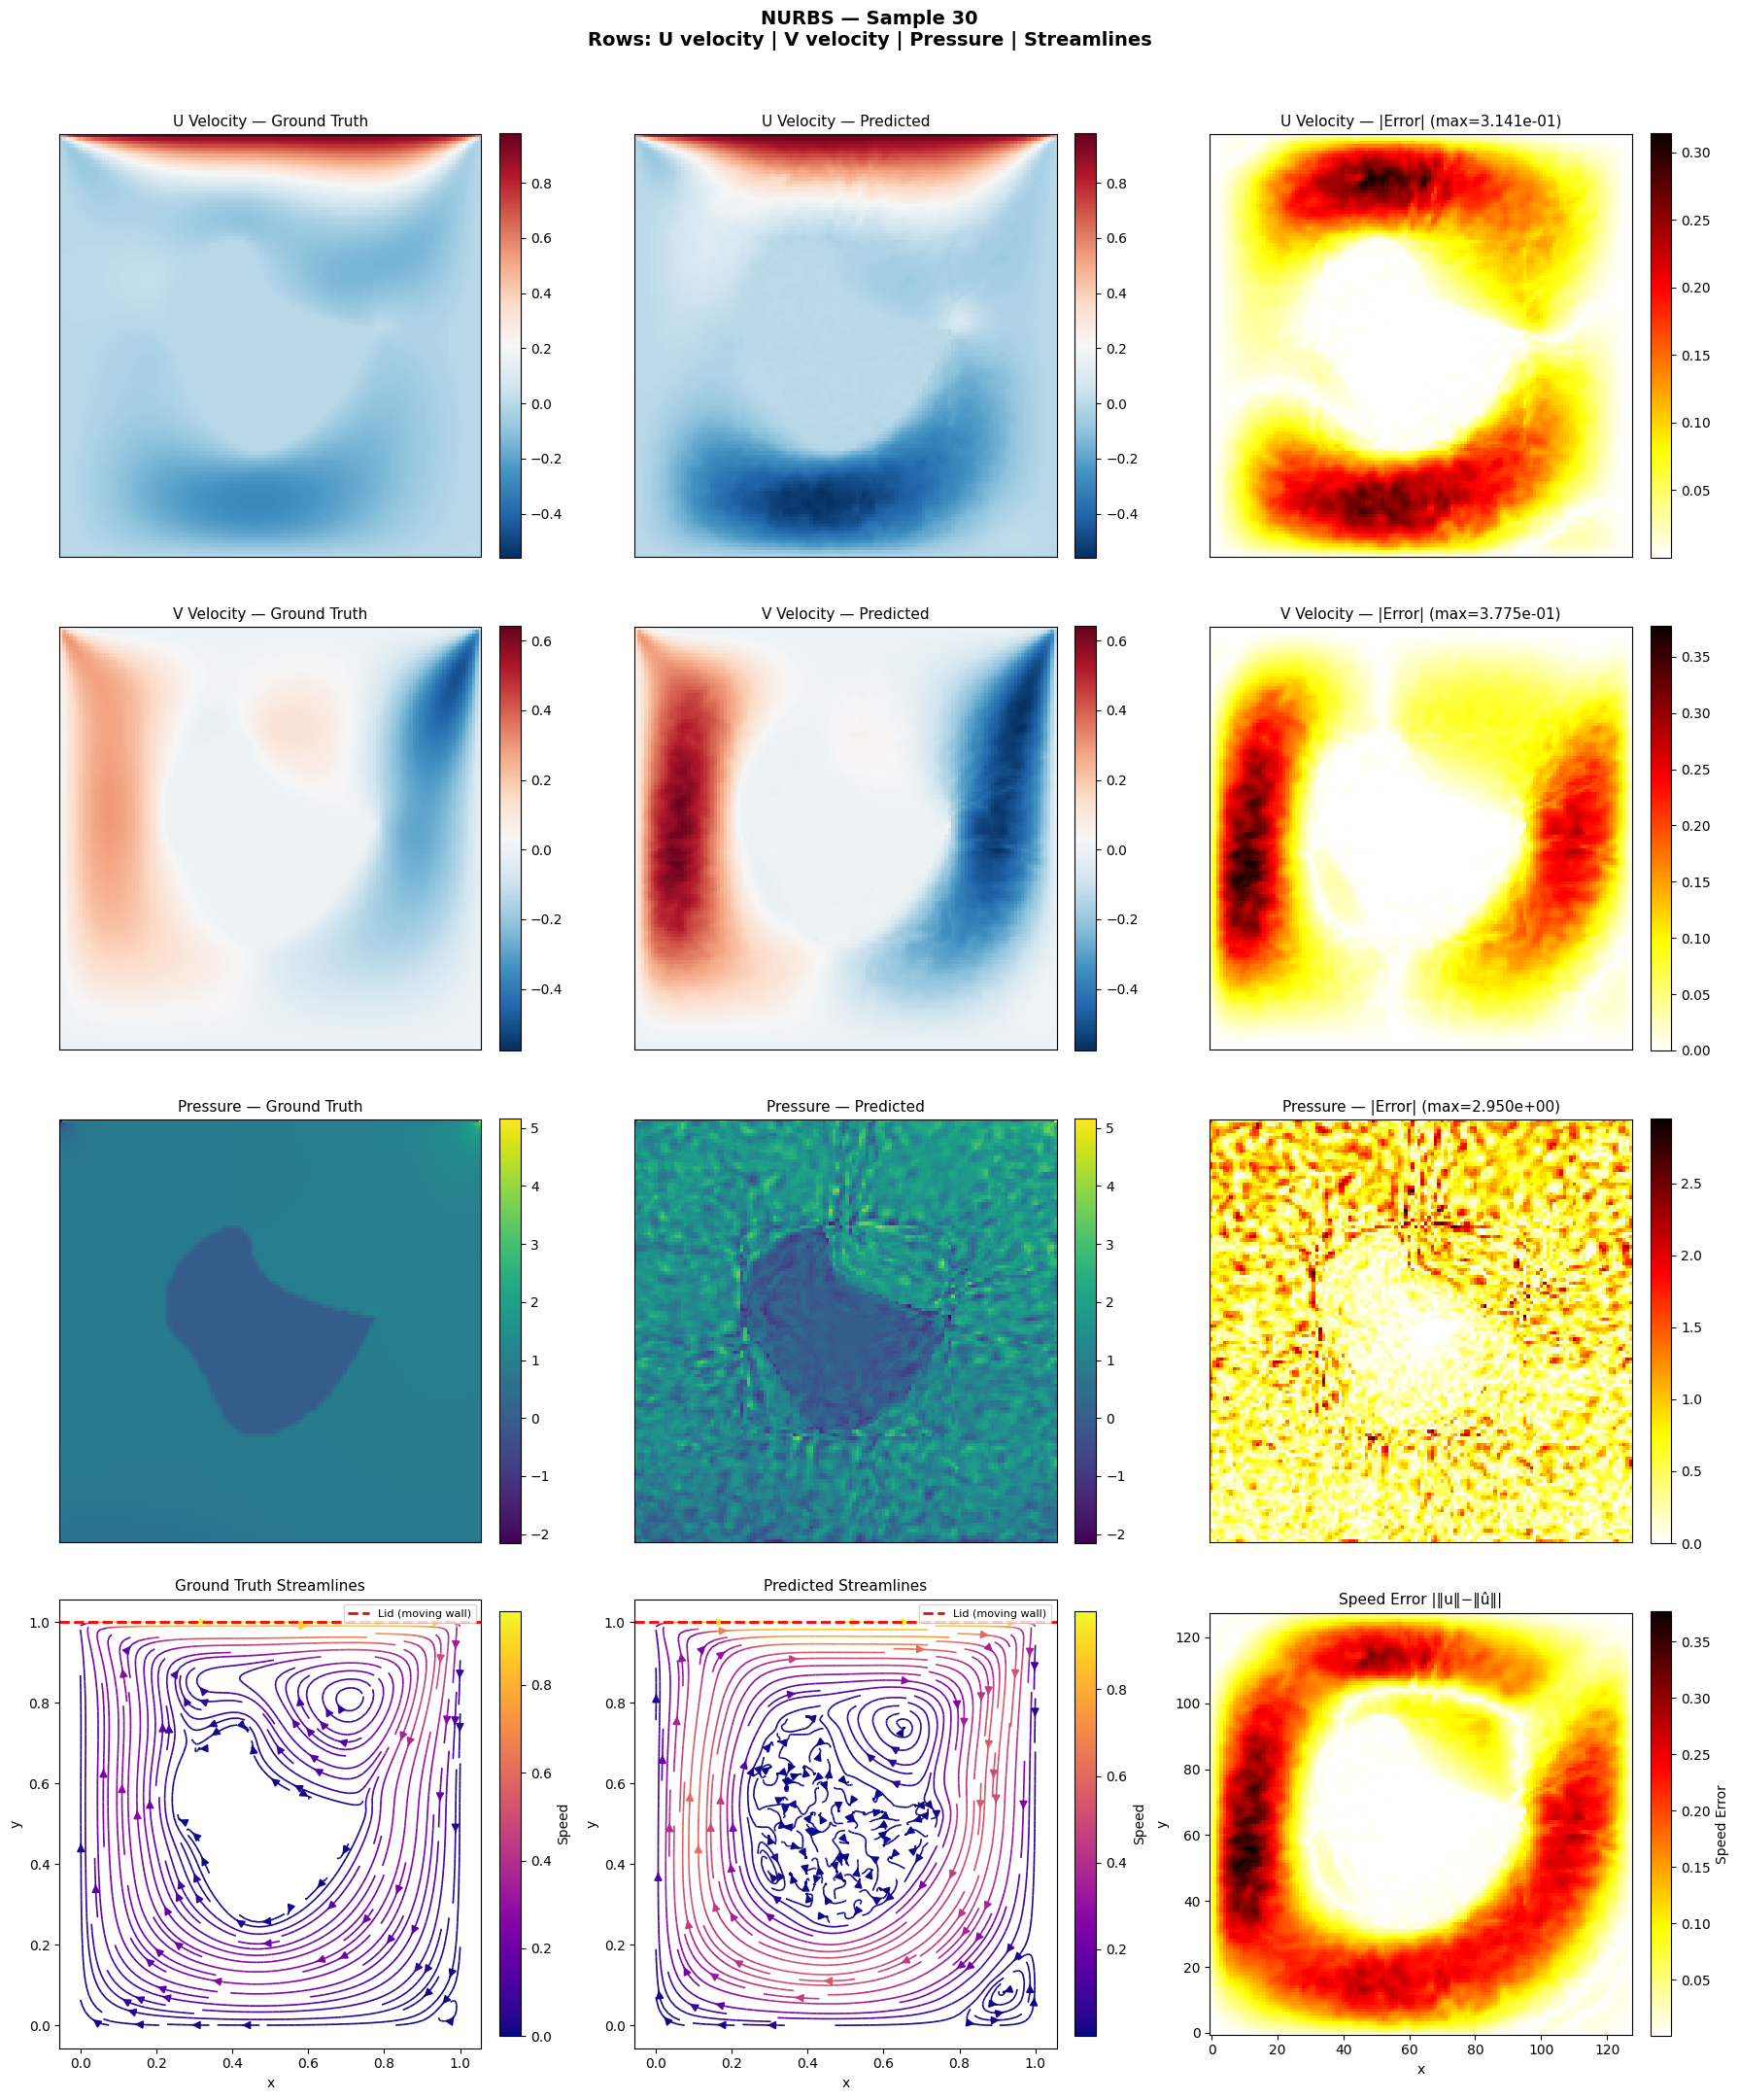

Saved: /content/drive/MyDrive/LDC_data/NURBS_sample139_streamlines.png


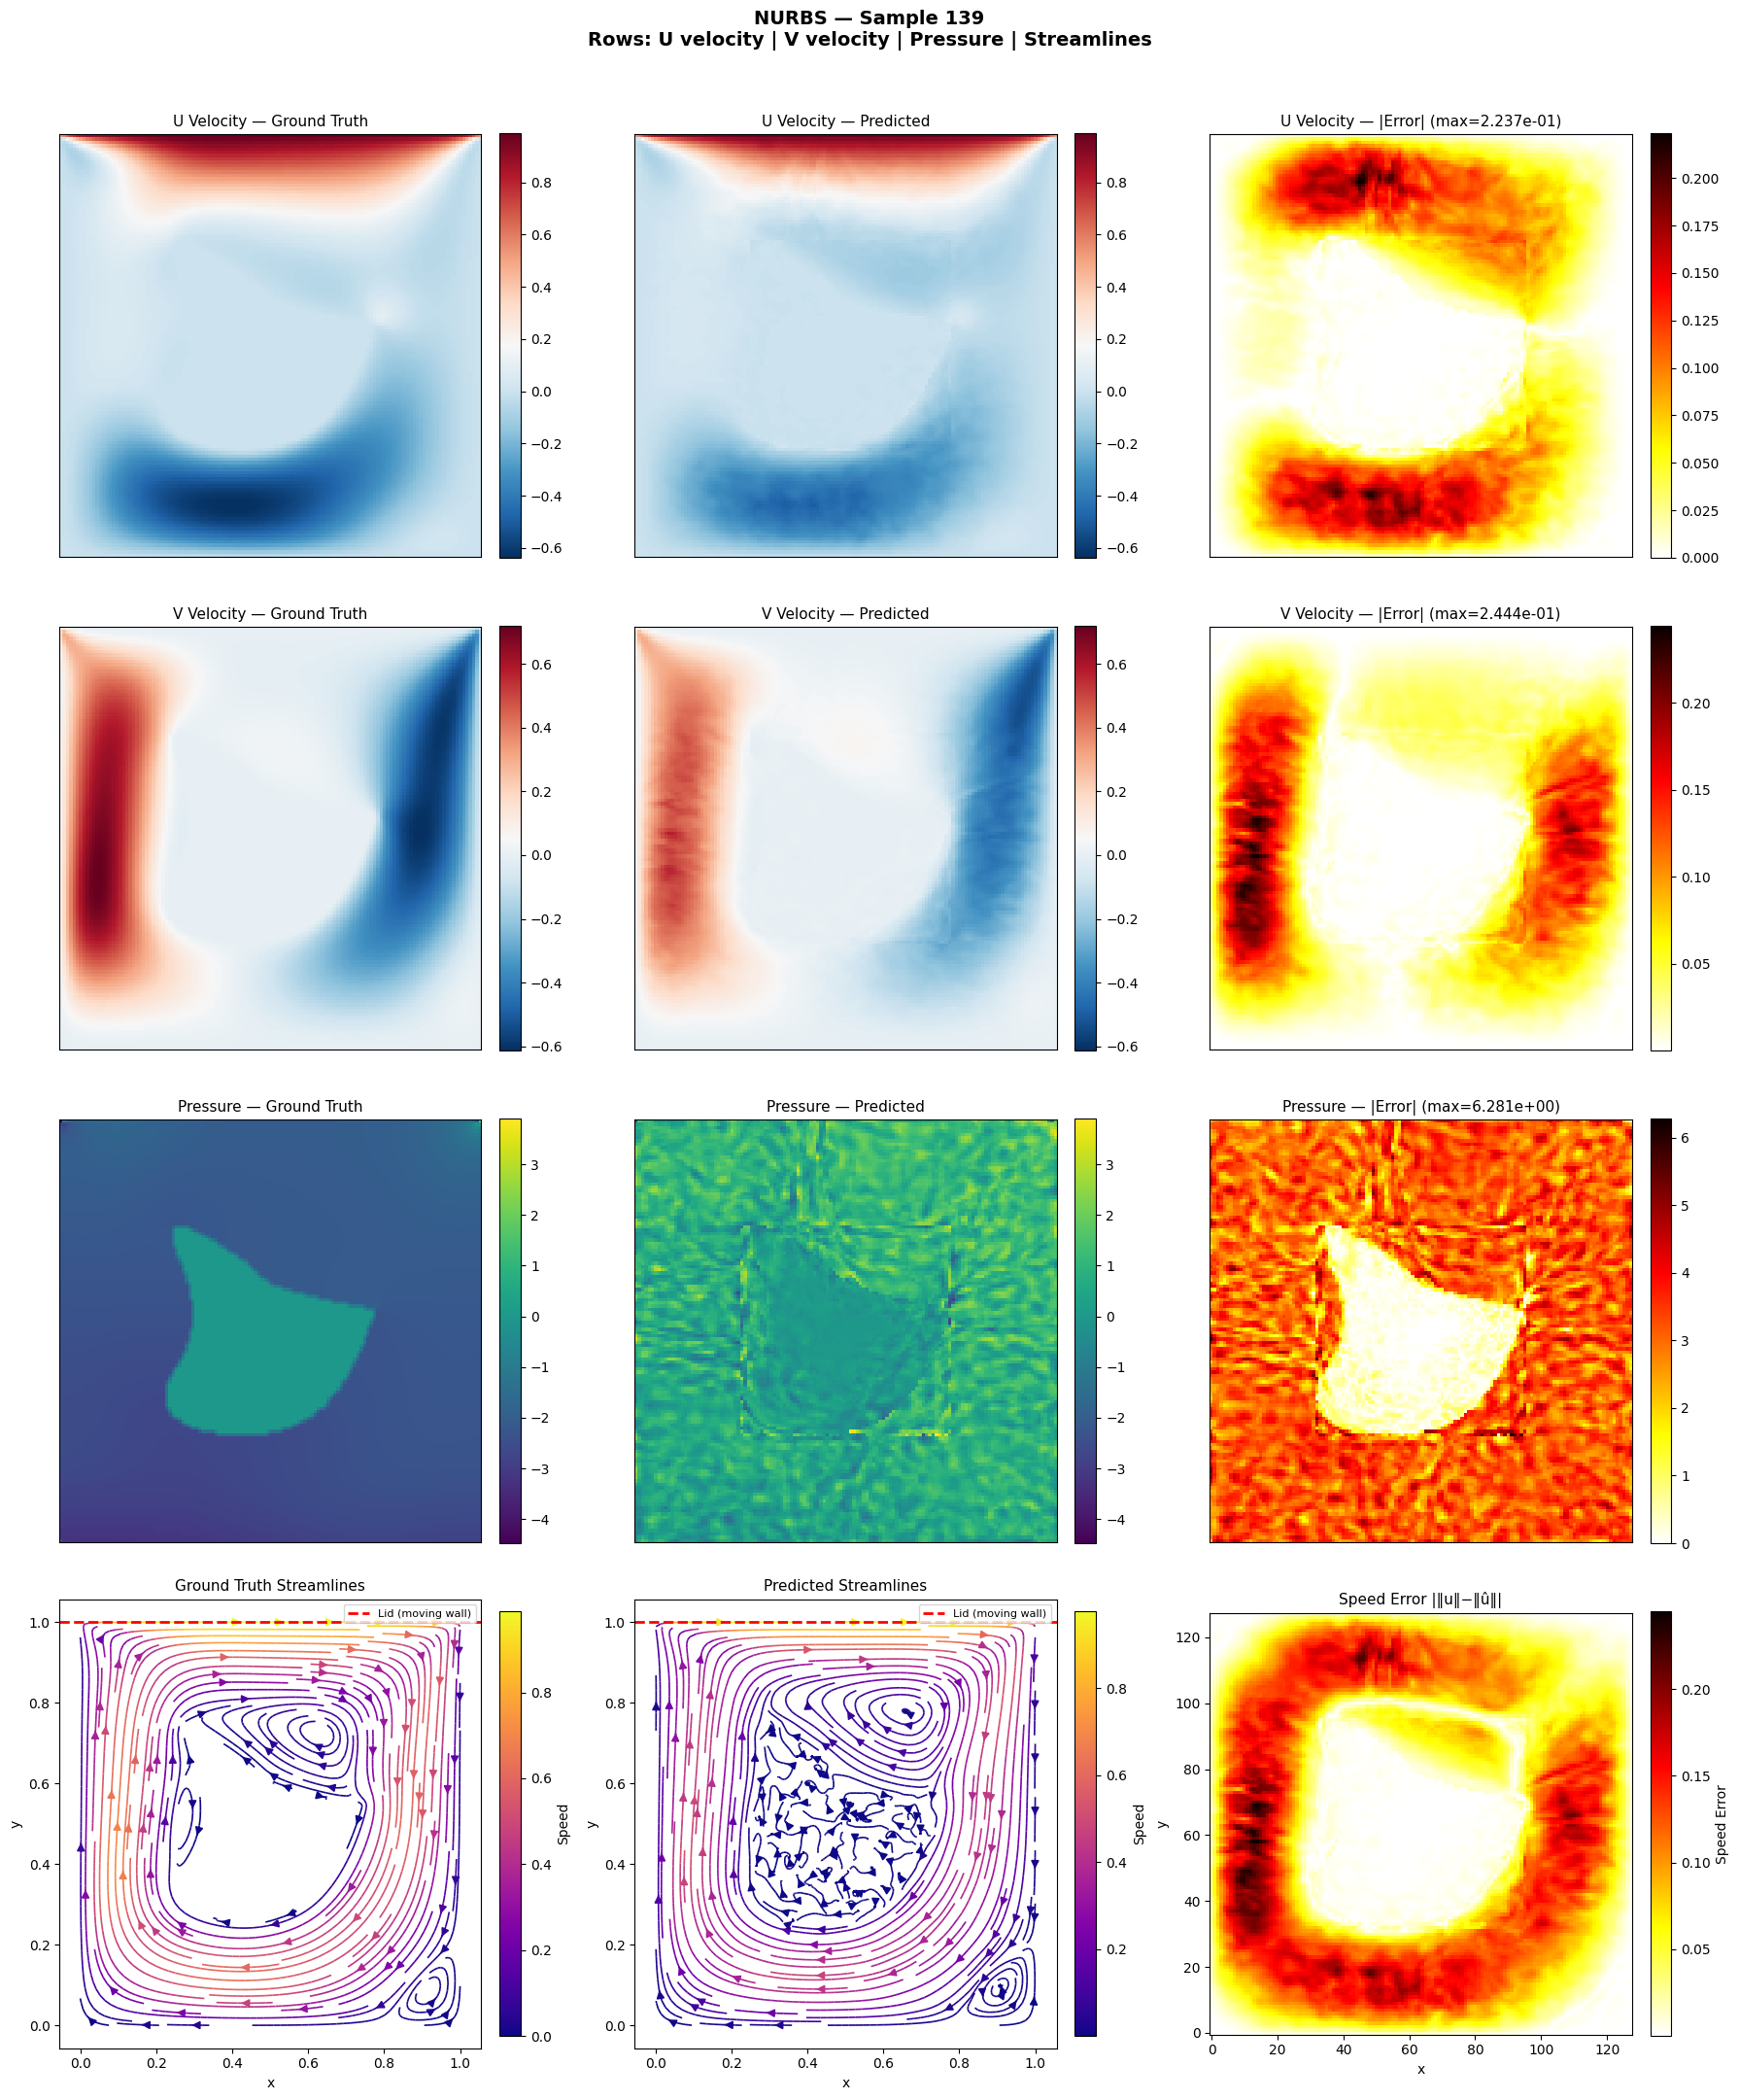

Saved: /content/drive/MyDrive/LDC_data/NURBS_sample129_streamlines.png


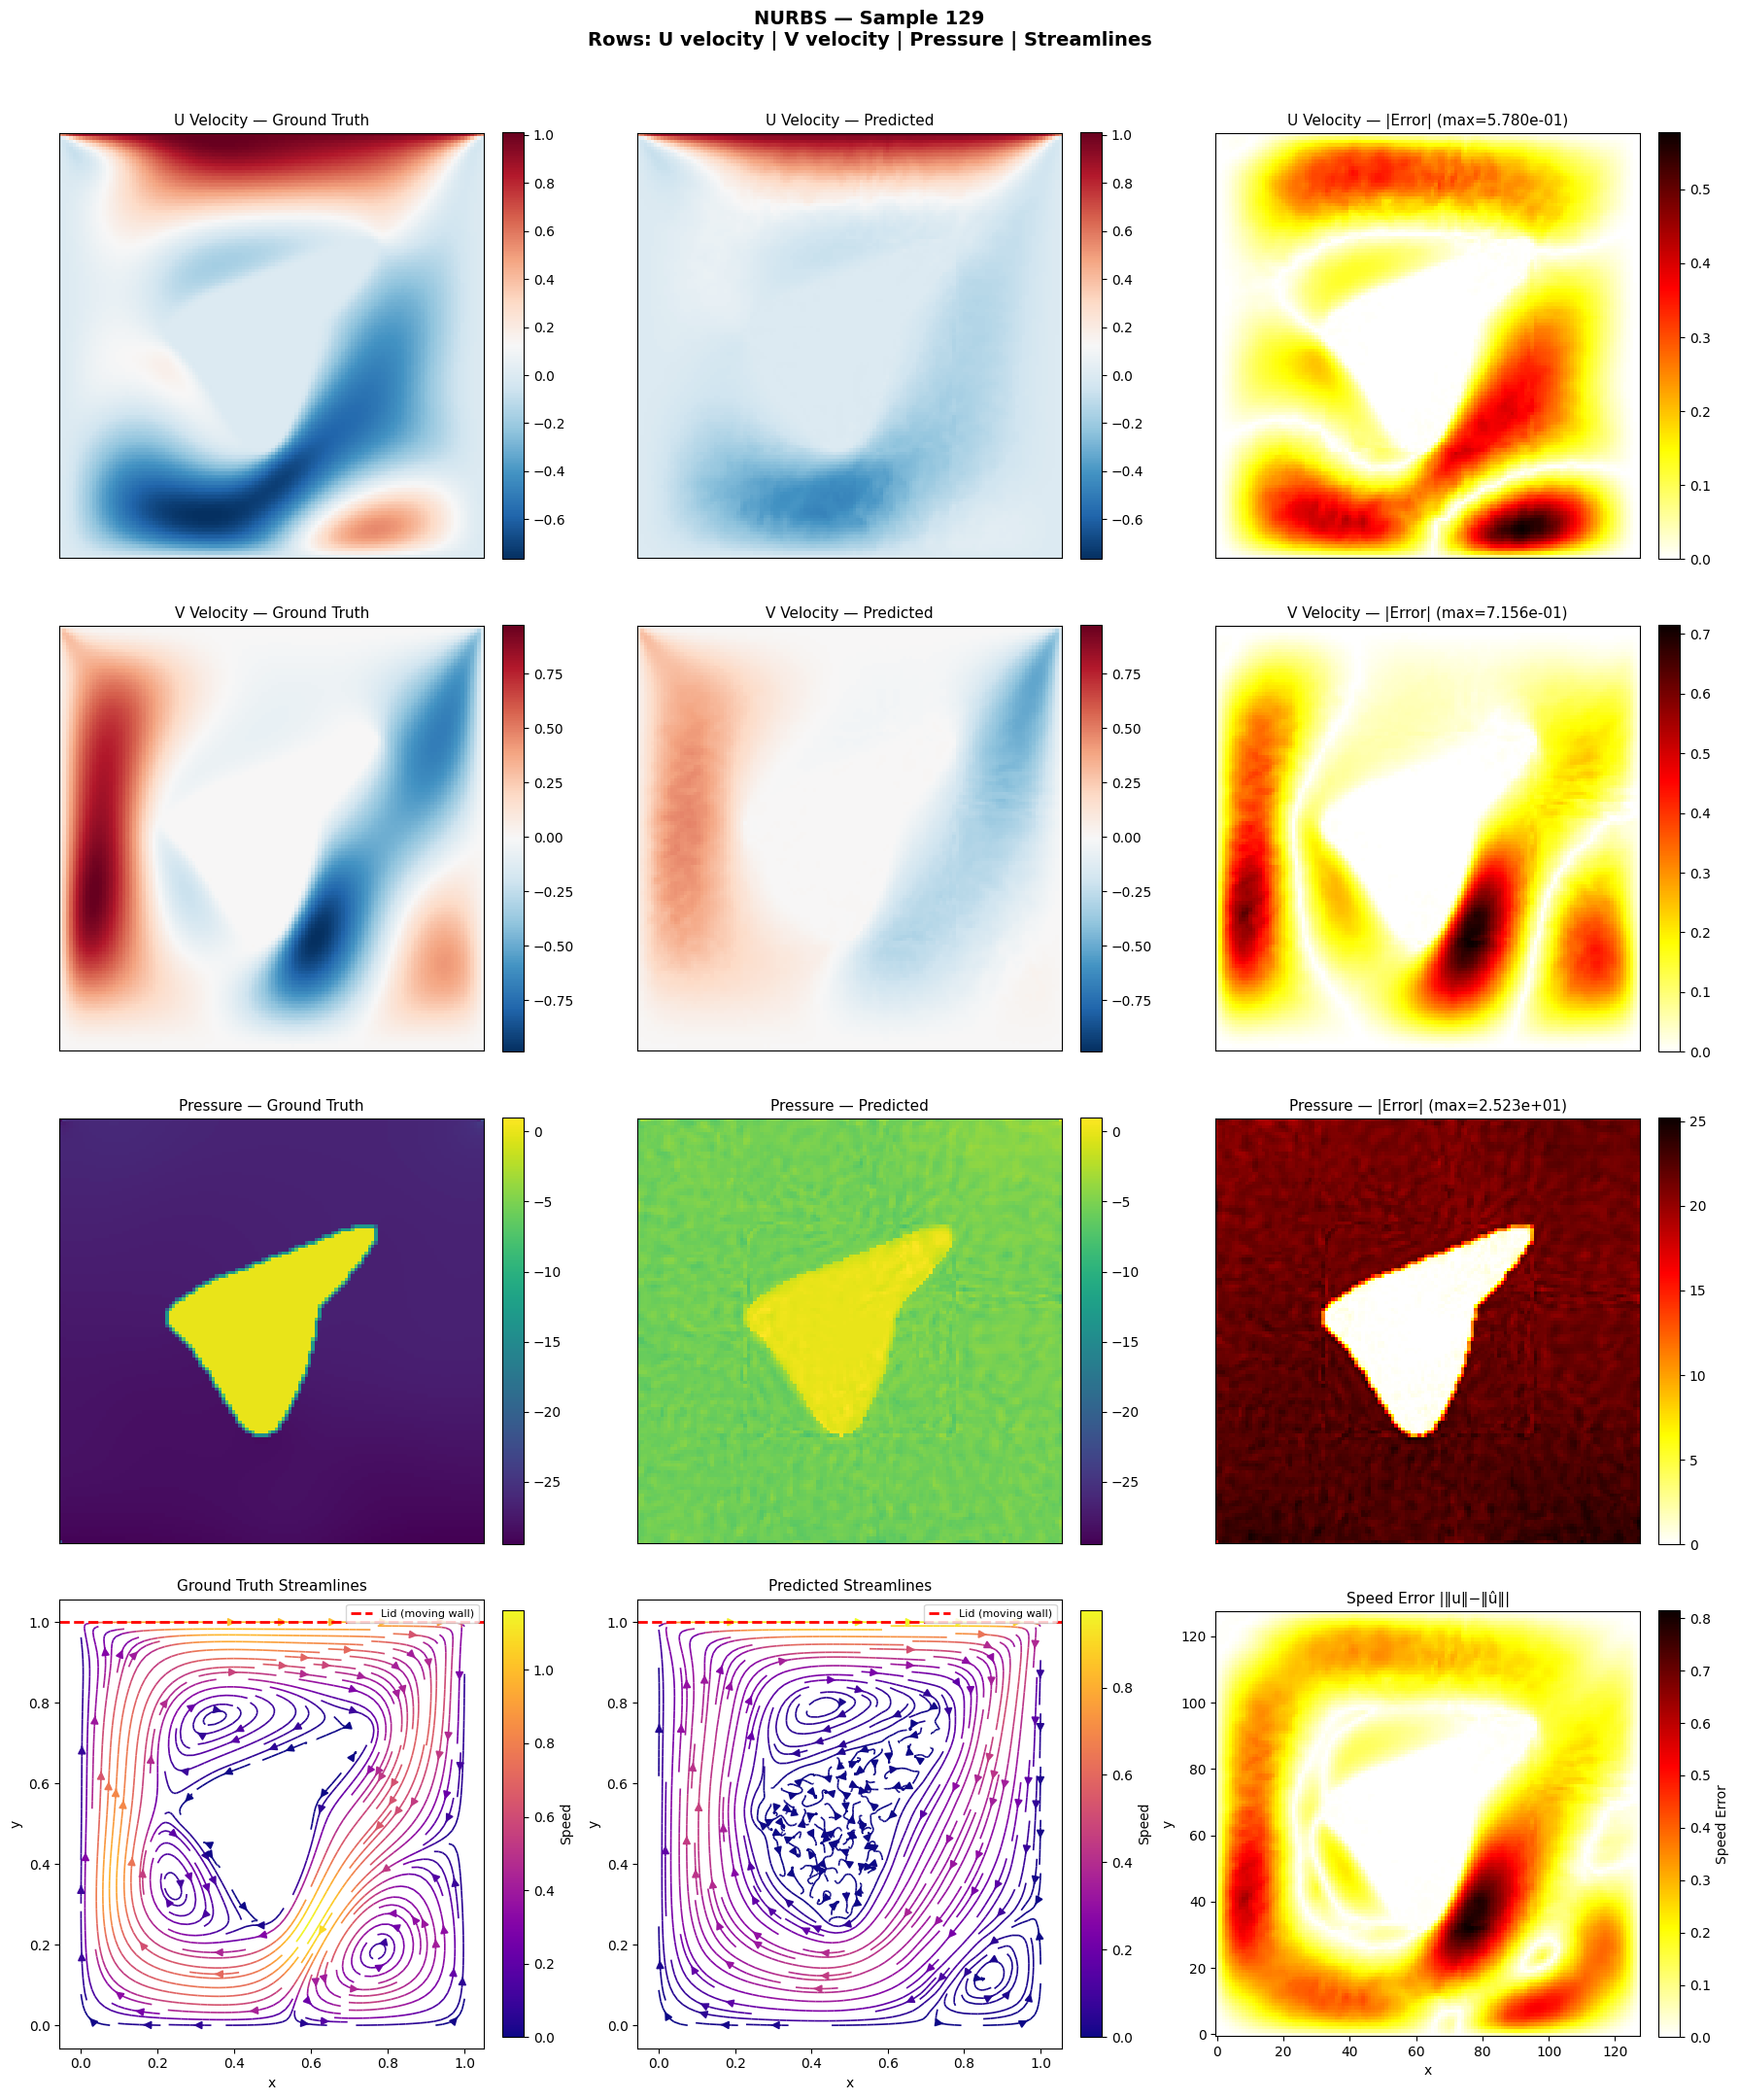


==== Training on Harmonics ====


Harmonics | Epoch   0 | Train L2: 1.0203 | Val L2: 0.9957 | Best: 0.9957 | LR: 3.00e-04
Harmonics | Epoch  20 | Train L2: 0.8374 | Val L2: 0.7317 | Best: 0.7172 | LR: 2.69e-04
Harmonics | Epoch  40 | Train L2: 0.8289 | Val L2: 0.7238 | Best: 0.7136 | LR: 1.92e-04
Harmonics | Epoch  60 | Train L2: 0.8213 | Val L2: 0.7207 | Best: 0.7118 | LR: 9.99e-05
Harmonics | Epoch  80 | Train L2: 0.8193 | Val L2: 0.7196 | Best: 0.7118 | LR: 2.69e-05

Harmonics done. Best Val L2: 0.7118


best_val_L2,█▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
lr,██████▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train_loss,█▅▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_rel_L2,█▆▄▃▄▃▃▃▃▃▂▂▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▂▁▂▁▁▂▂▁▃▂▂▂▃▂▂▂▃▃▃▃▃▃▃▃▃▄▄▃▃▃▄▄▄▄▄▄▄▄
val_rel_L2,█▆▅▃▄▂▂▂▂▂▂▂▂▂▁▁▂▁▁▂▁▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_L2,0.7118
epoch,99
lr,0.0
train_loss,0.66277



==== Visualizing Harmonics ====


Saved: /content/drive/MyDrive/LDC_data/Harmonics_sample105_streamlines.png


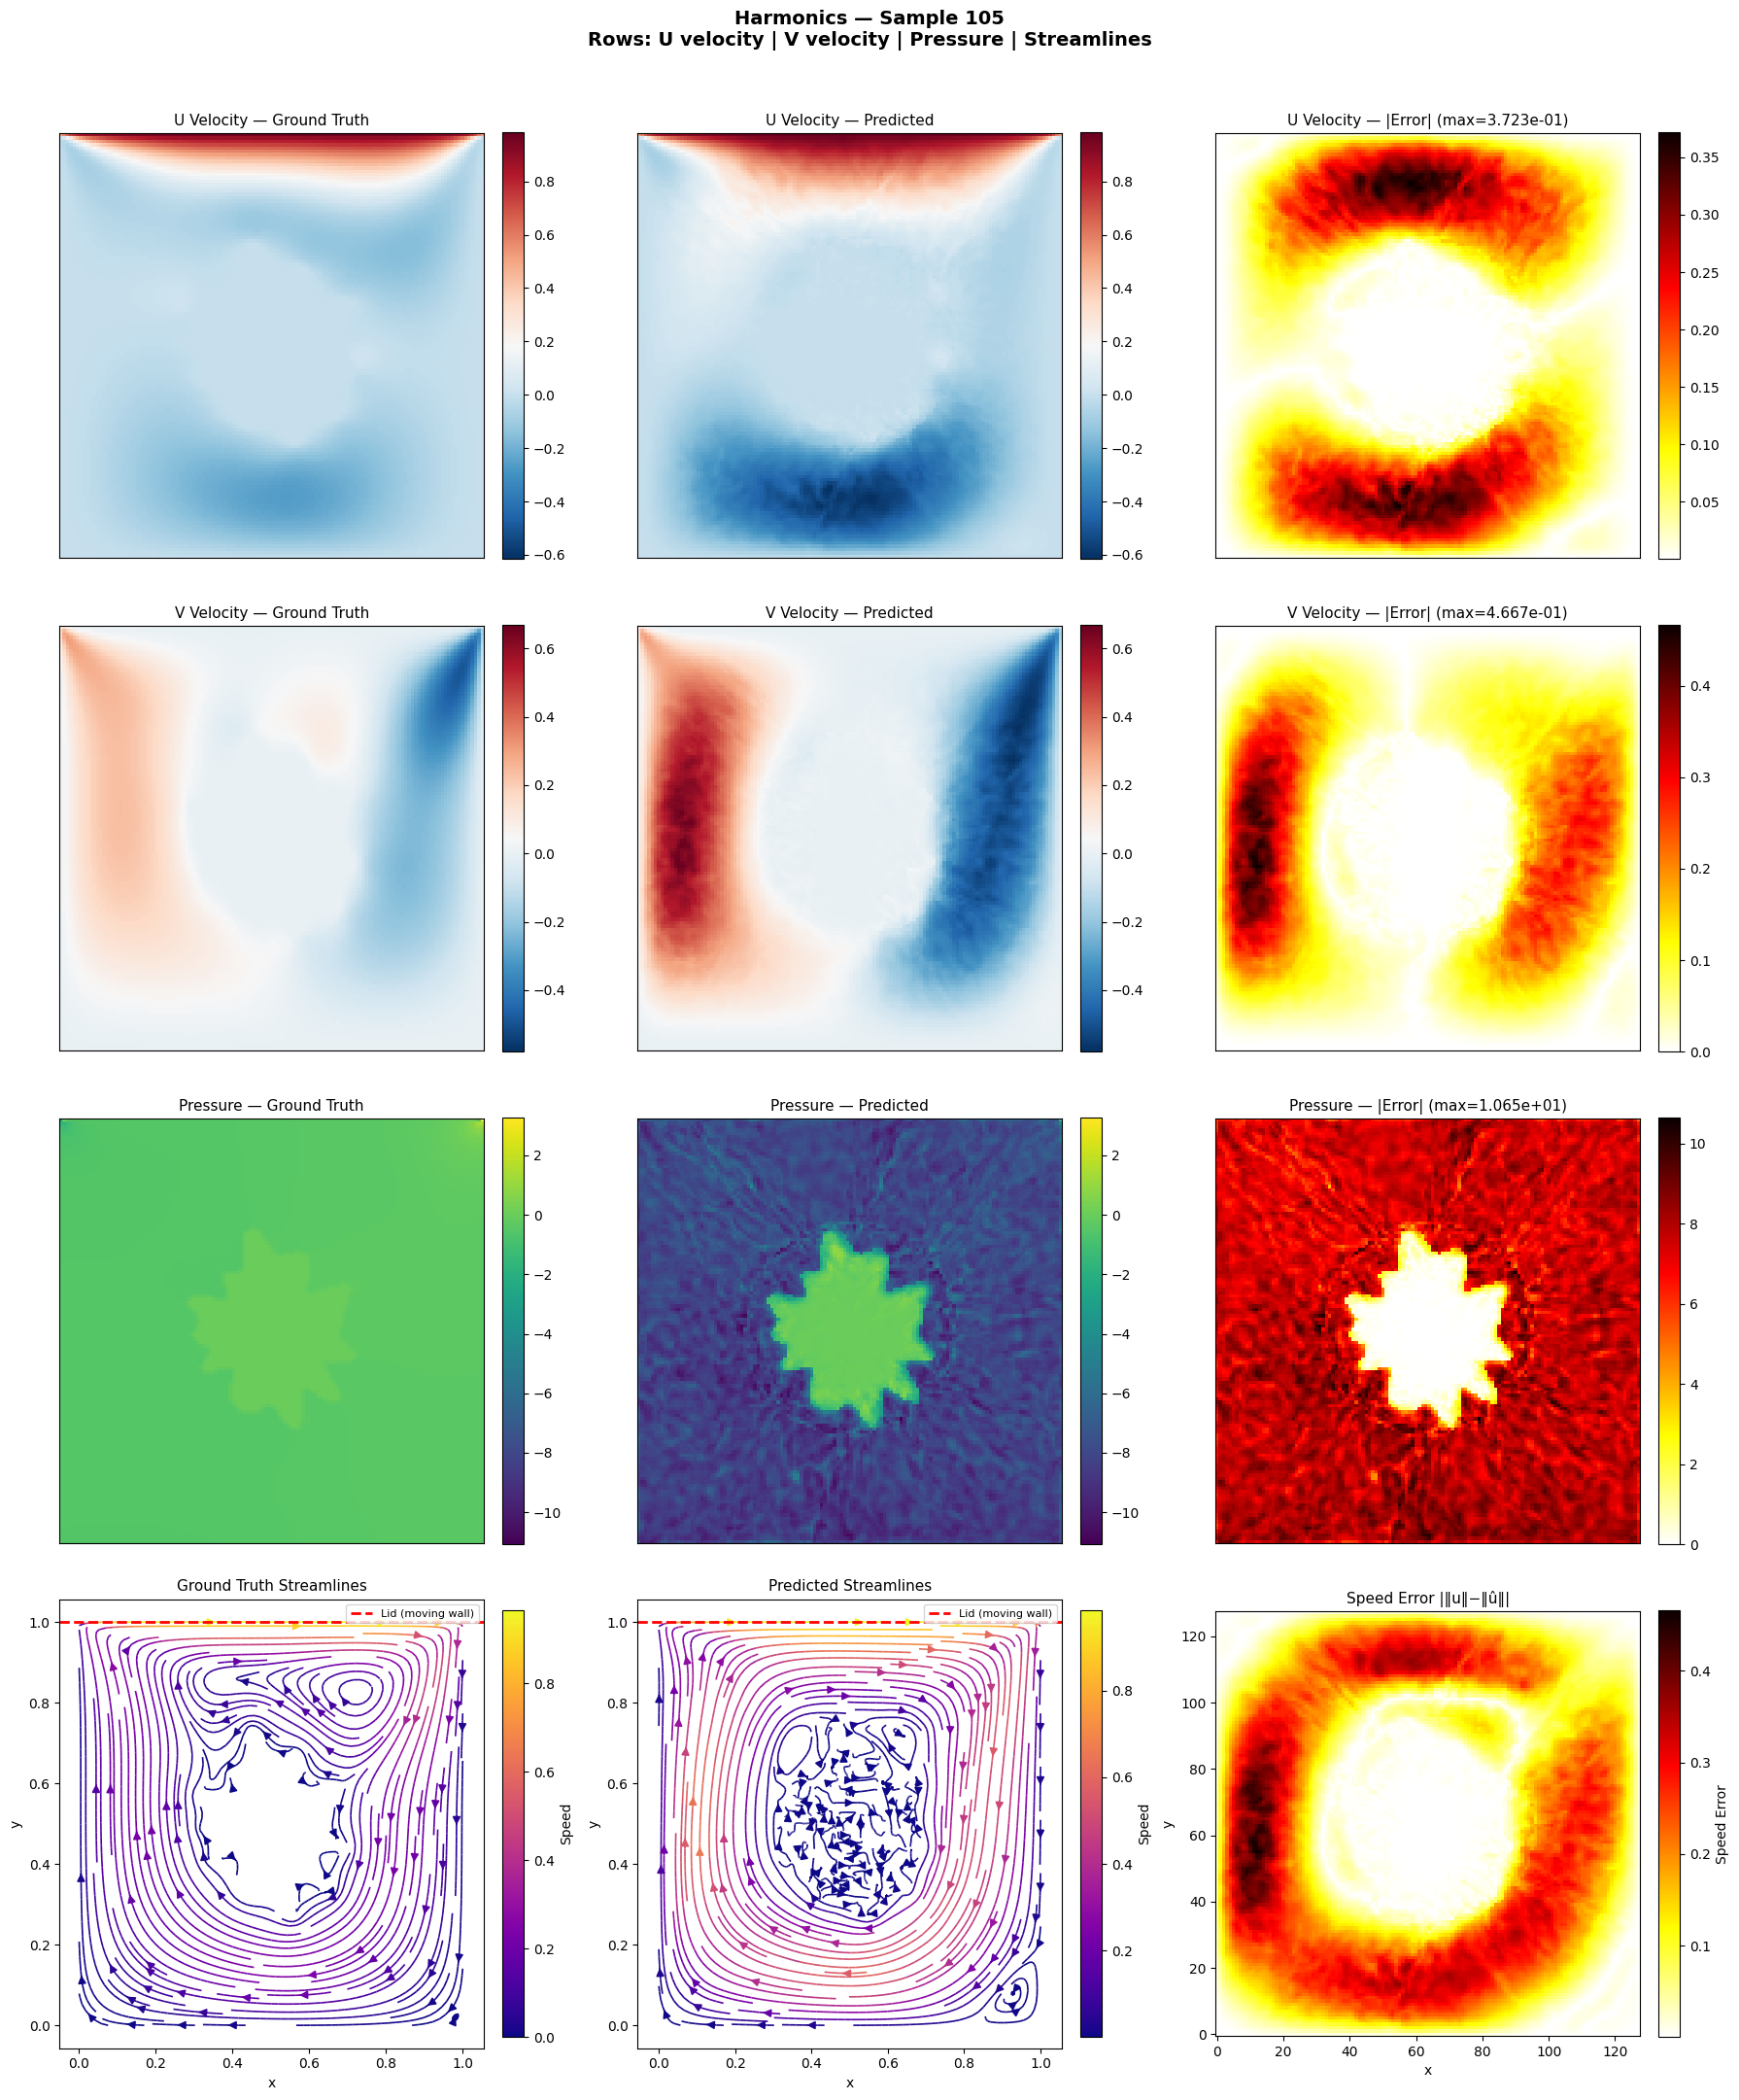

Saved: /content/drive/MyDrive/LDC_data/Harmonics_sample61_streamlines.png


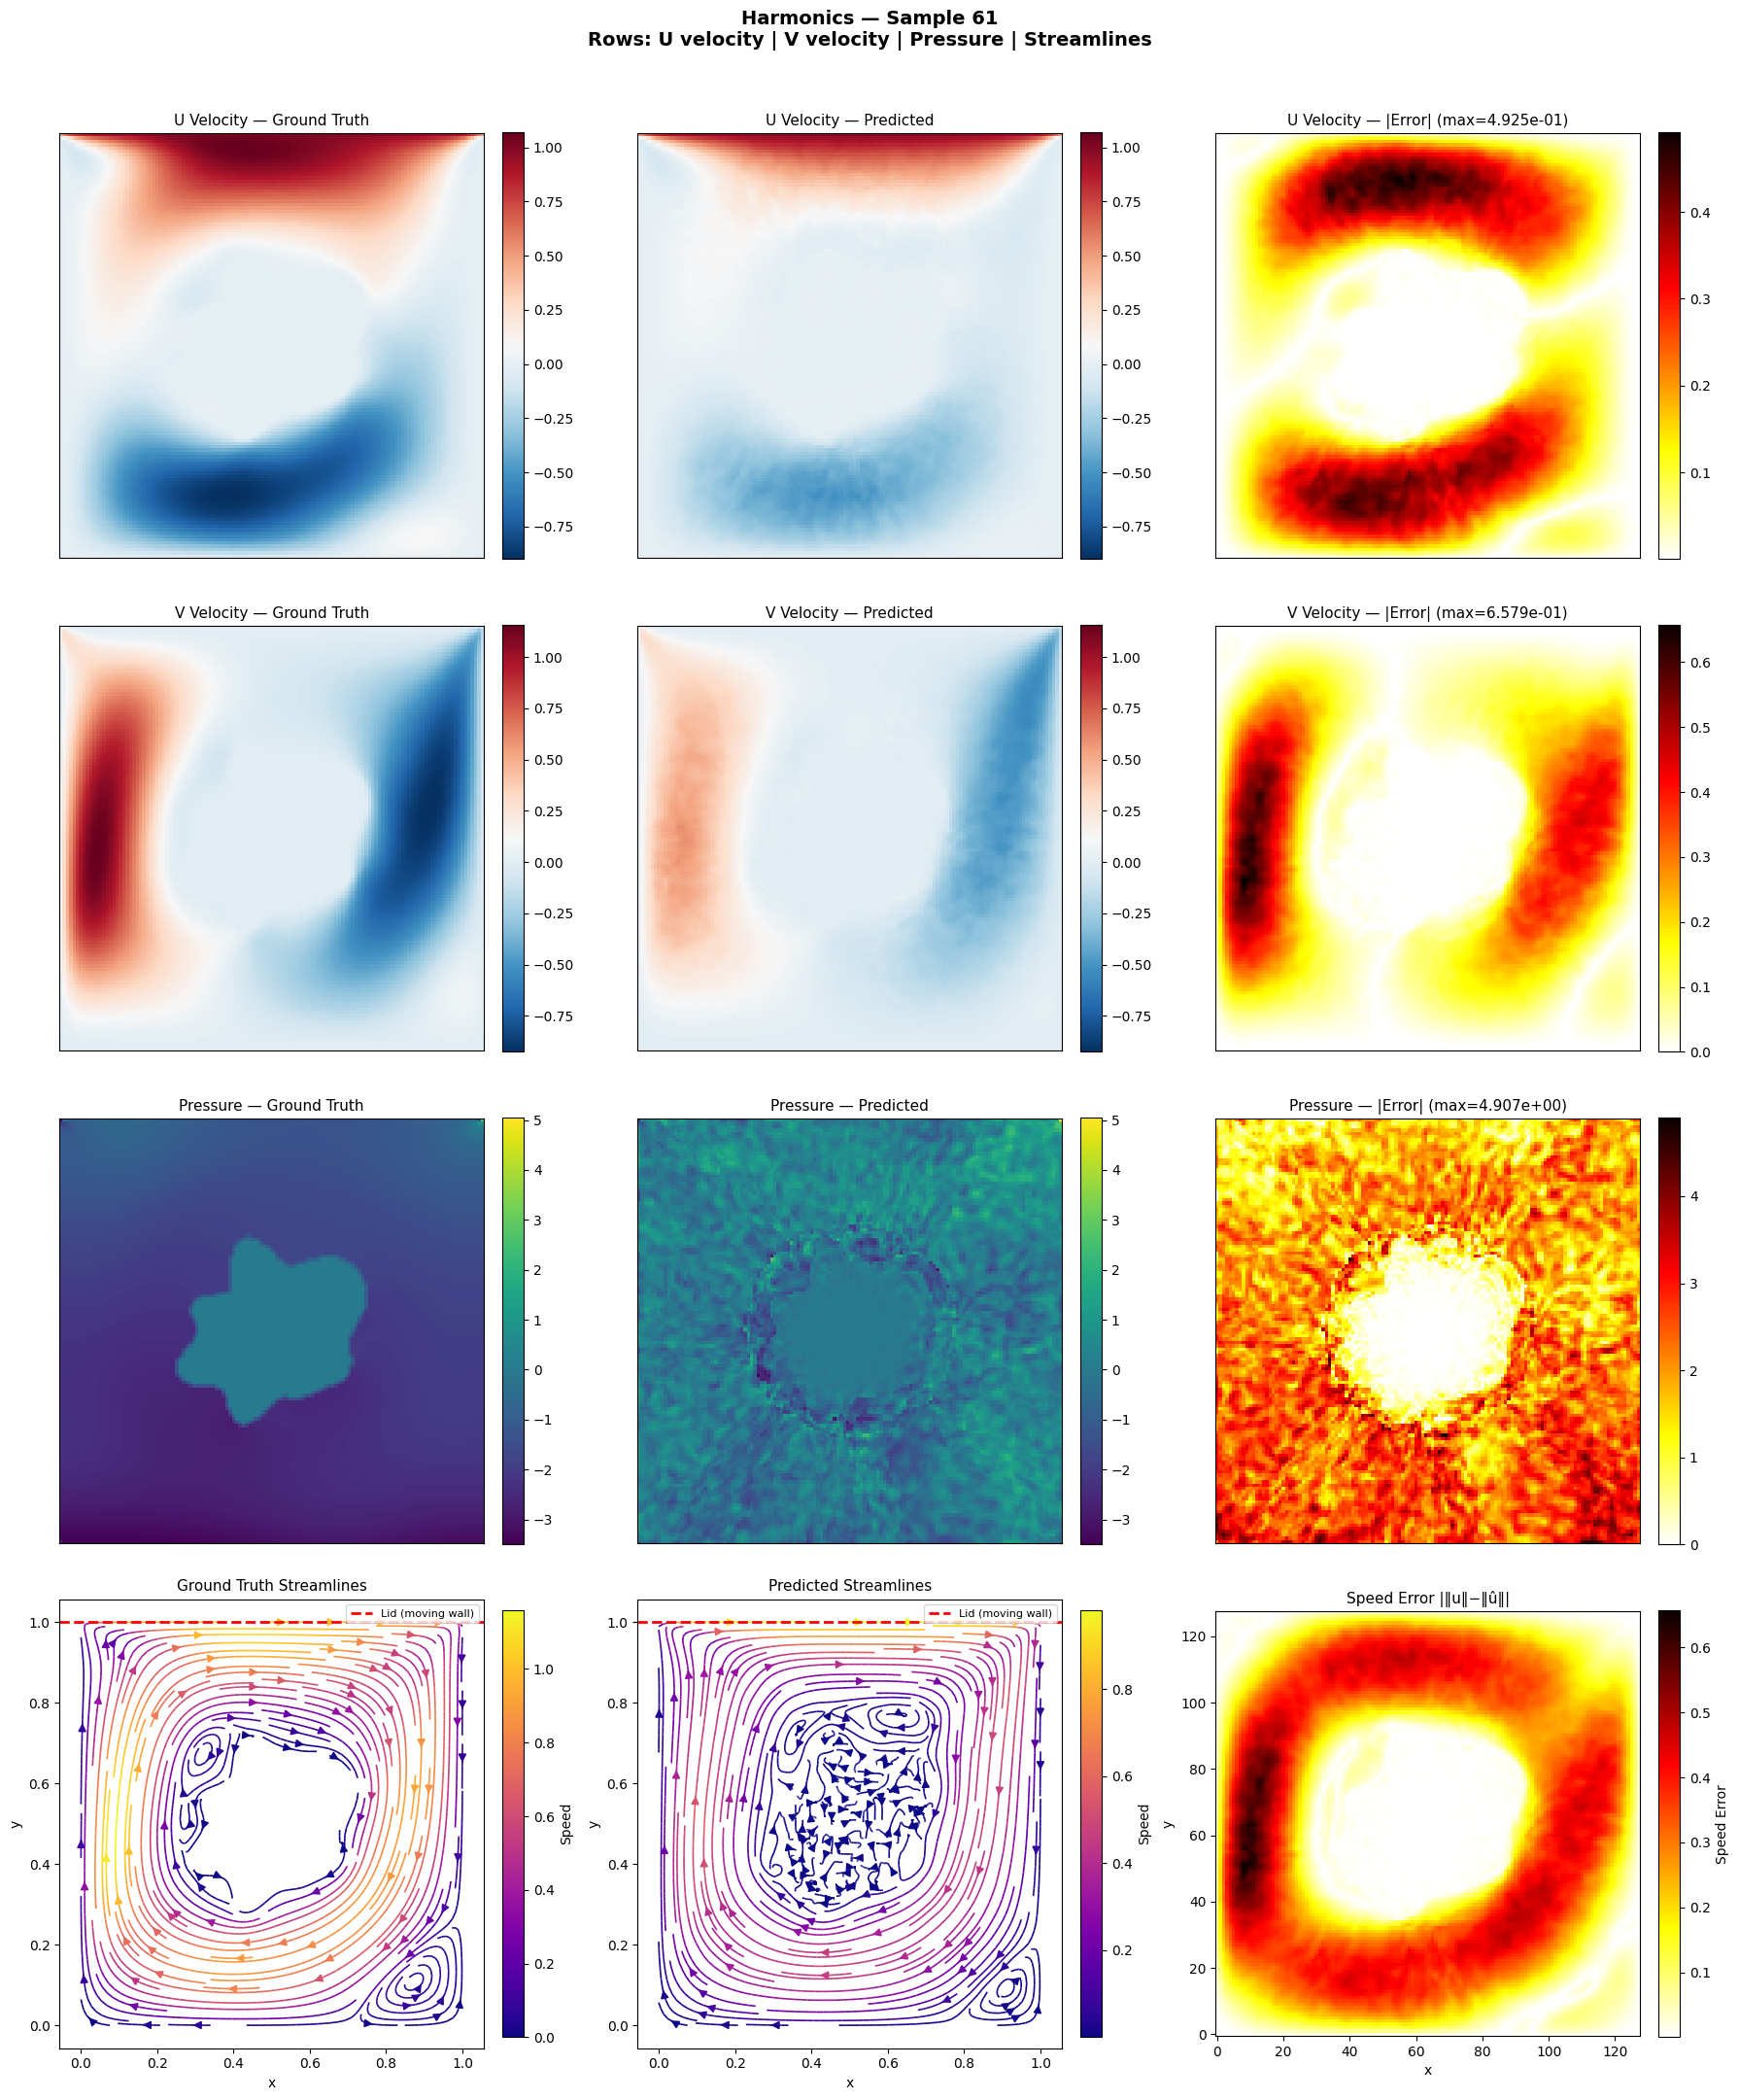

Saved: /content/drive/MyDrive/LDC_data/Harmonics_sample159_streamlines.png


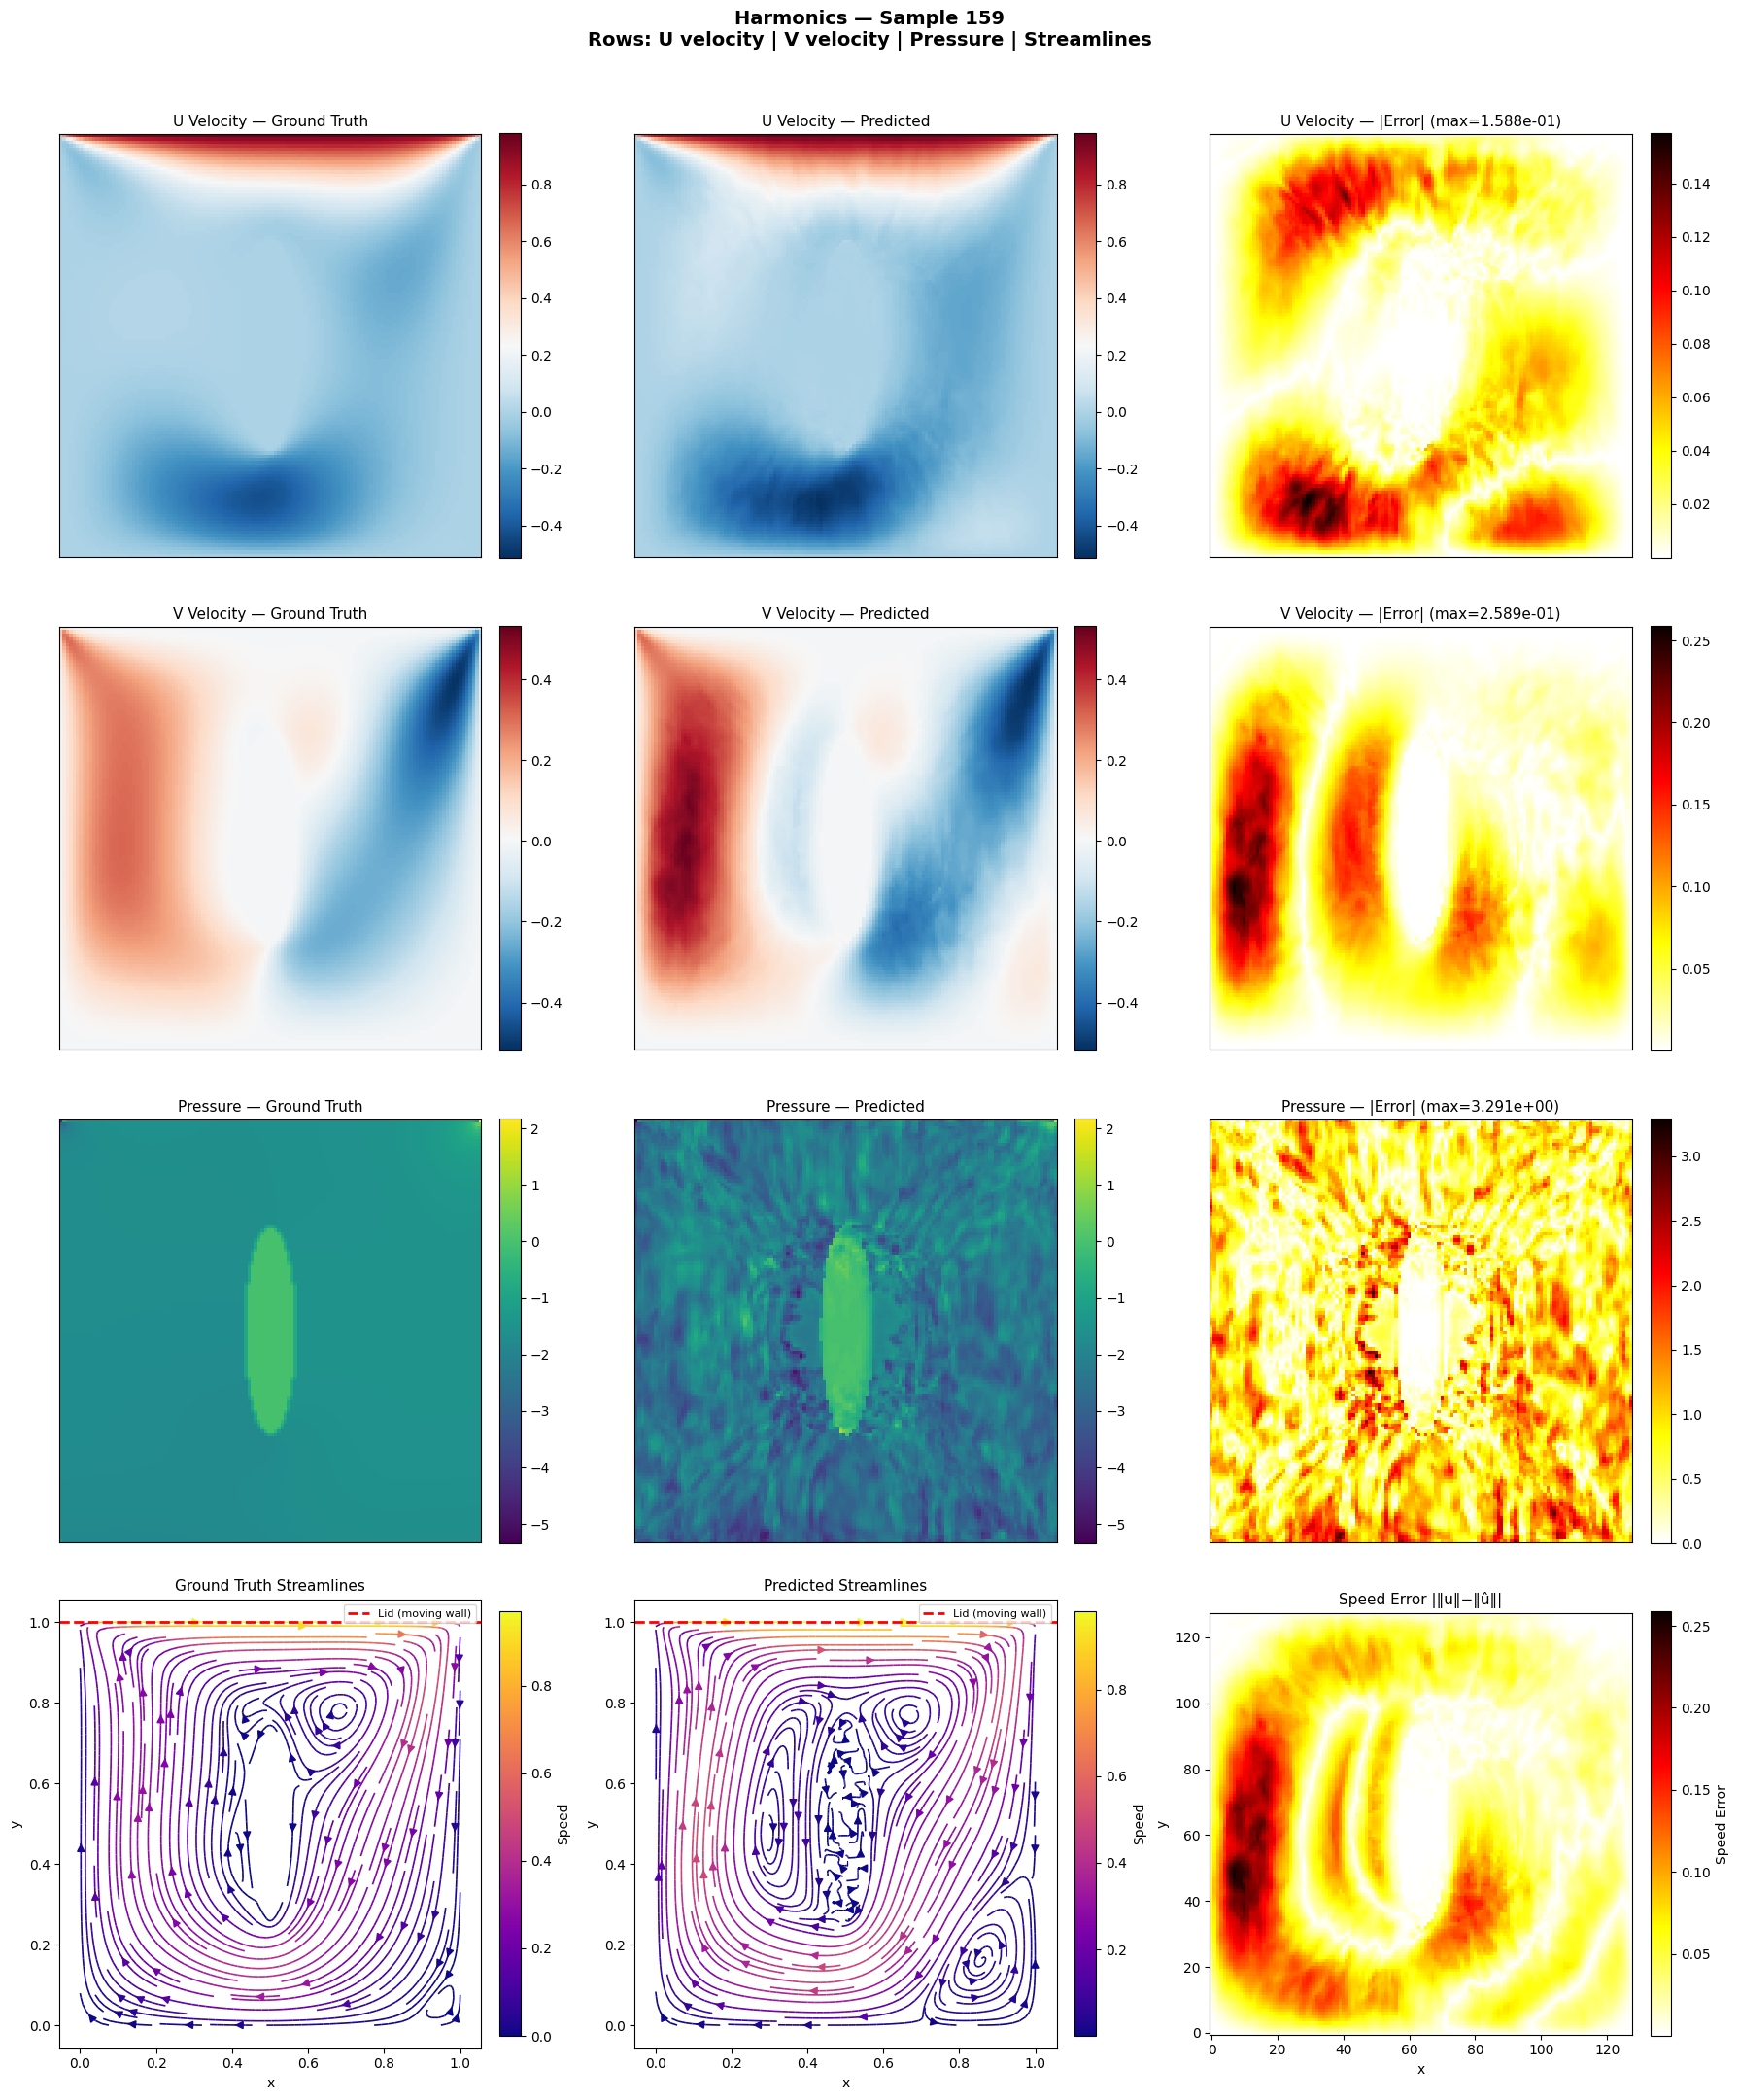


==== Training on Skelneton ====


Skelneton | Epoch   0 | Train L2: 1.0150 | Val L2: 1.0395 | Best: 1.0395 | LR: 3.00e-04
Skelneton | Epoch  20 | Train L2: 0.8302 | Val L2: 0.6902 | Best: 0.6749 | LR: 2.69e-04
Skelneton | Epoch  40 | Train L2: 0.8155 | Val L2: 0.7205 | Best: 0.6749 | LR: 1.92e-04
Skelneton | Epoch  60 | Train L2: 0.8056 | Val L2: 0.7073 | Best: 0.6749 | LR: 9.99e-05
Skelneton | Epoch  80 | Train L2: 0.8004 | Val L2: 0.7025 | Best: 0.6749 | LR: 2.69e-05

Skelneton done. Best Val L2: 0.6749


best_val_L2,█▇▆▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
lr,████████▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_rel_L2,█▇▇▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▂
val_loss,█▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_rel_L2,█▅▄▁▁▁▁▂▁▁▁▁▂▁▁▂▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_L2,0.6749
epoch,99
lr,0.0
train_loss,0.59413



==== Visualizing Skelneton ====


Saved: /content/drive/MyDrive/LDC_data/Skelneton_sample120_streamlines.png


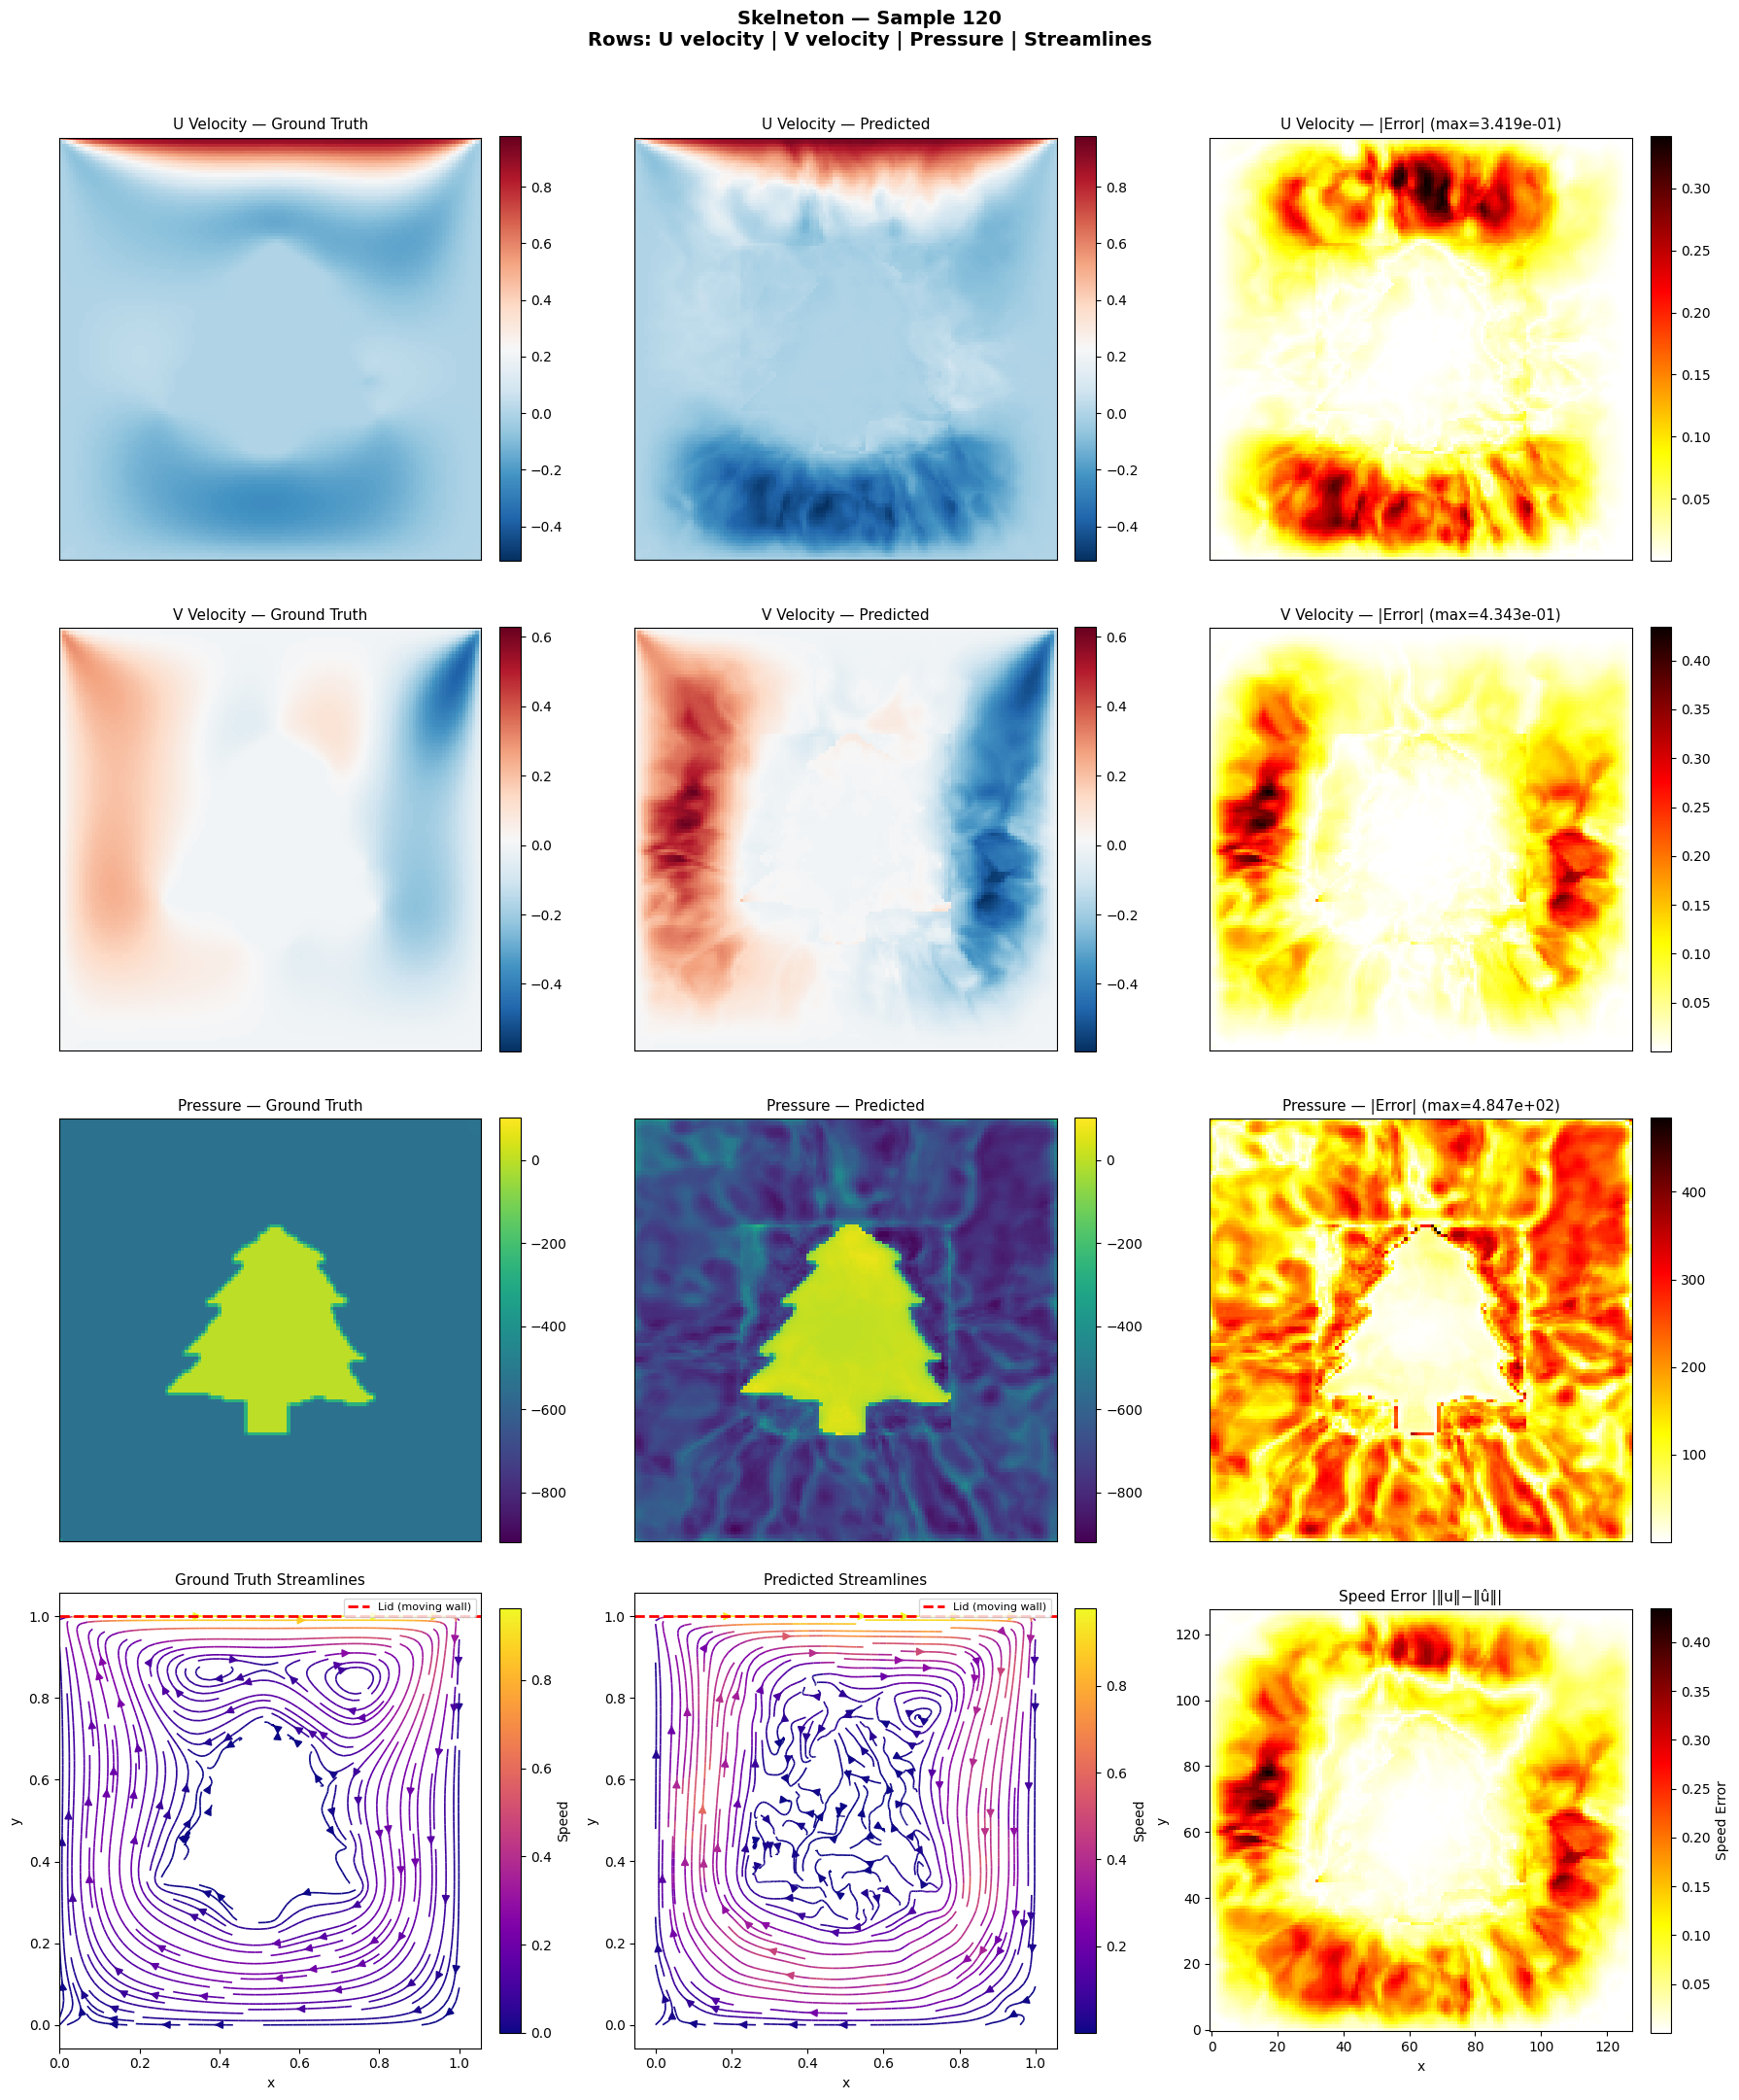

Saved: /content/drive/MyDrive/LDC_data/Skelneton_sample86_streamlines.png


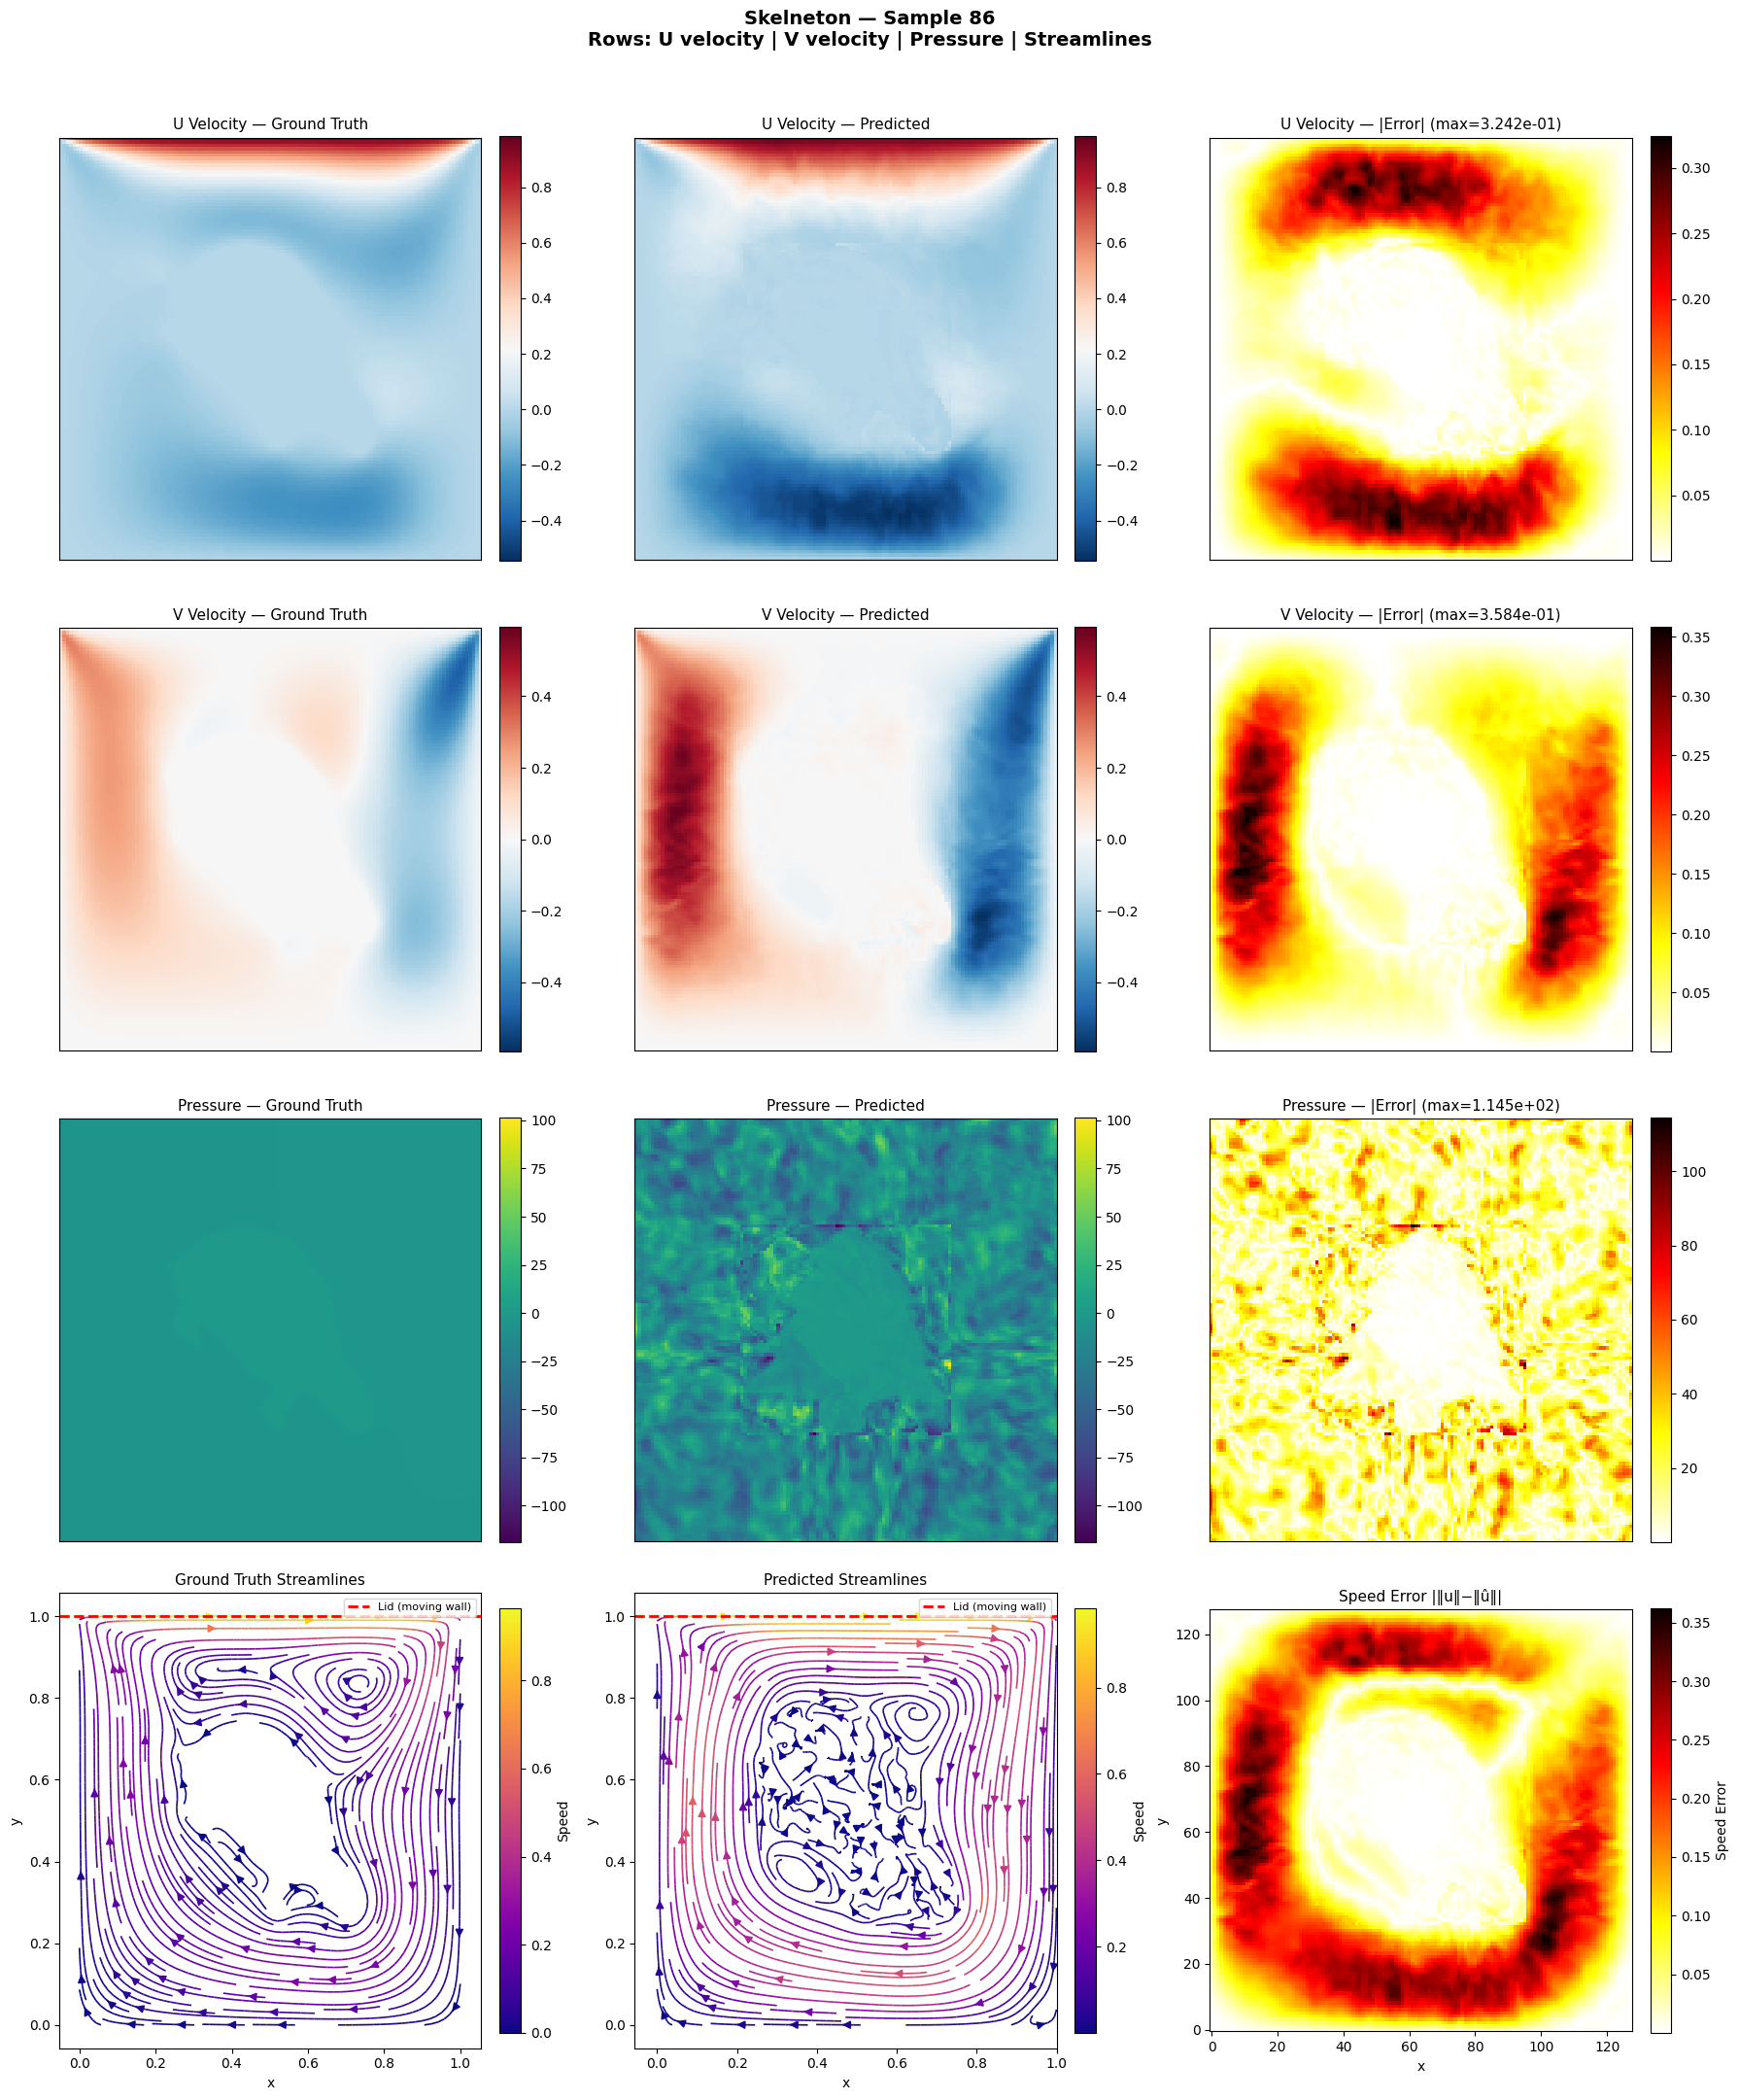

Saved: /content/drive/MyDrive/LDC_data/Skelneton_sample42_streamlines.png


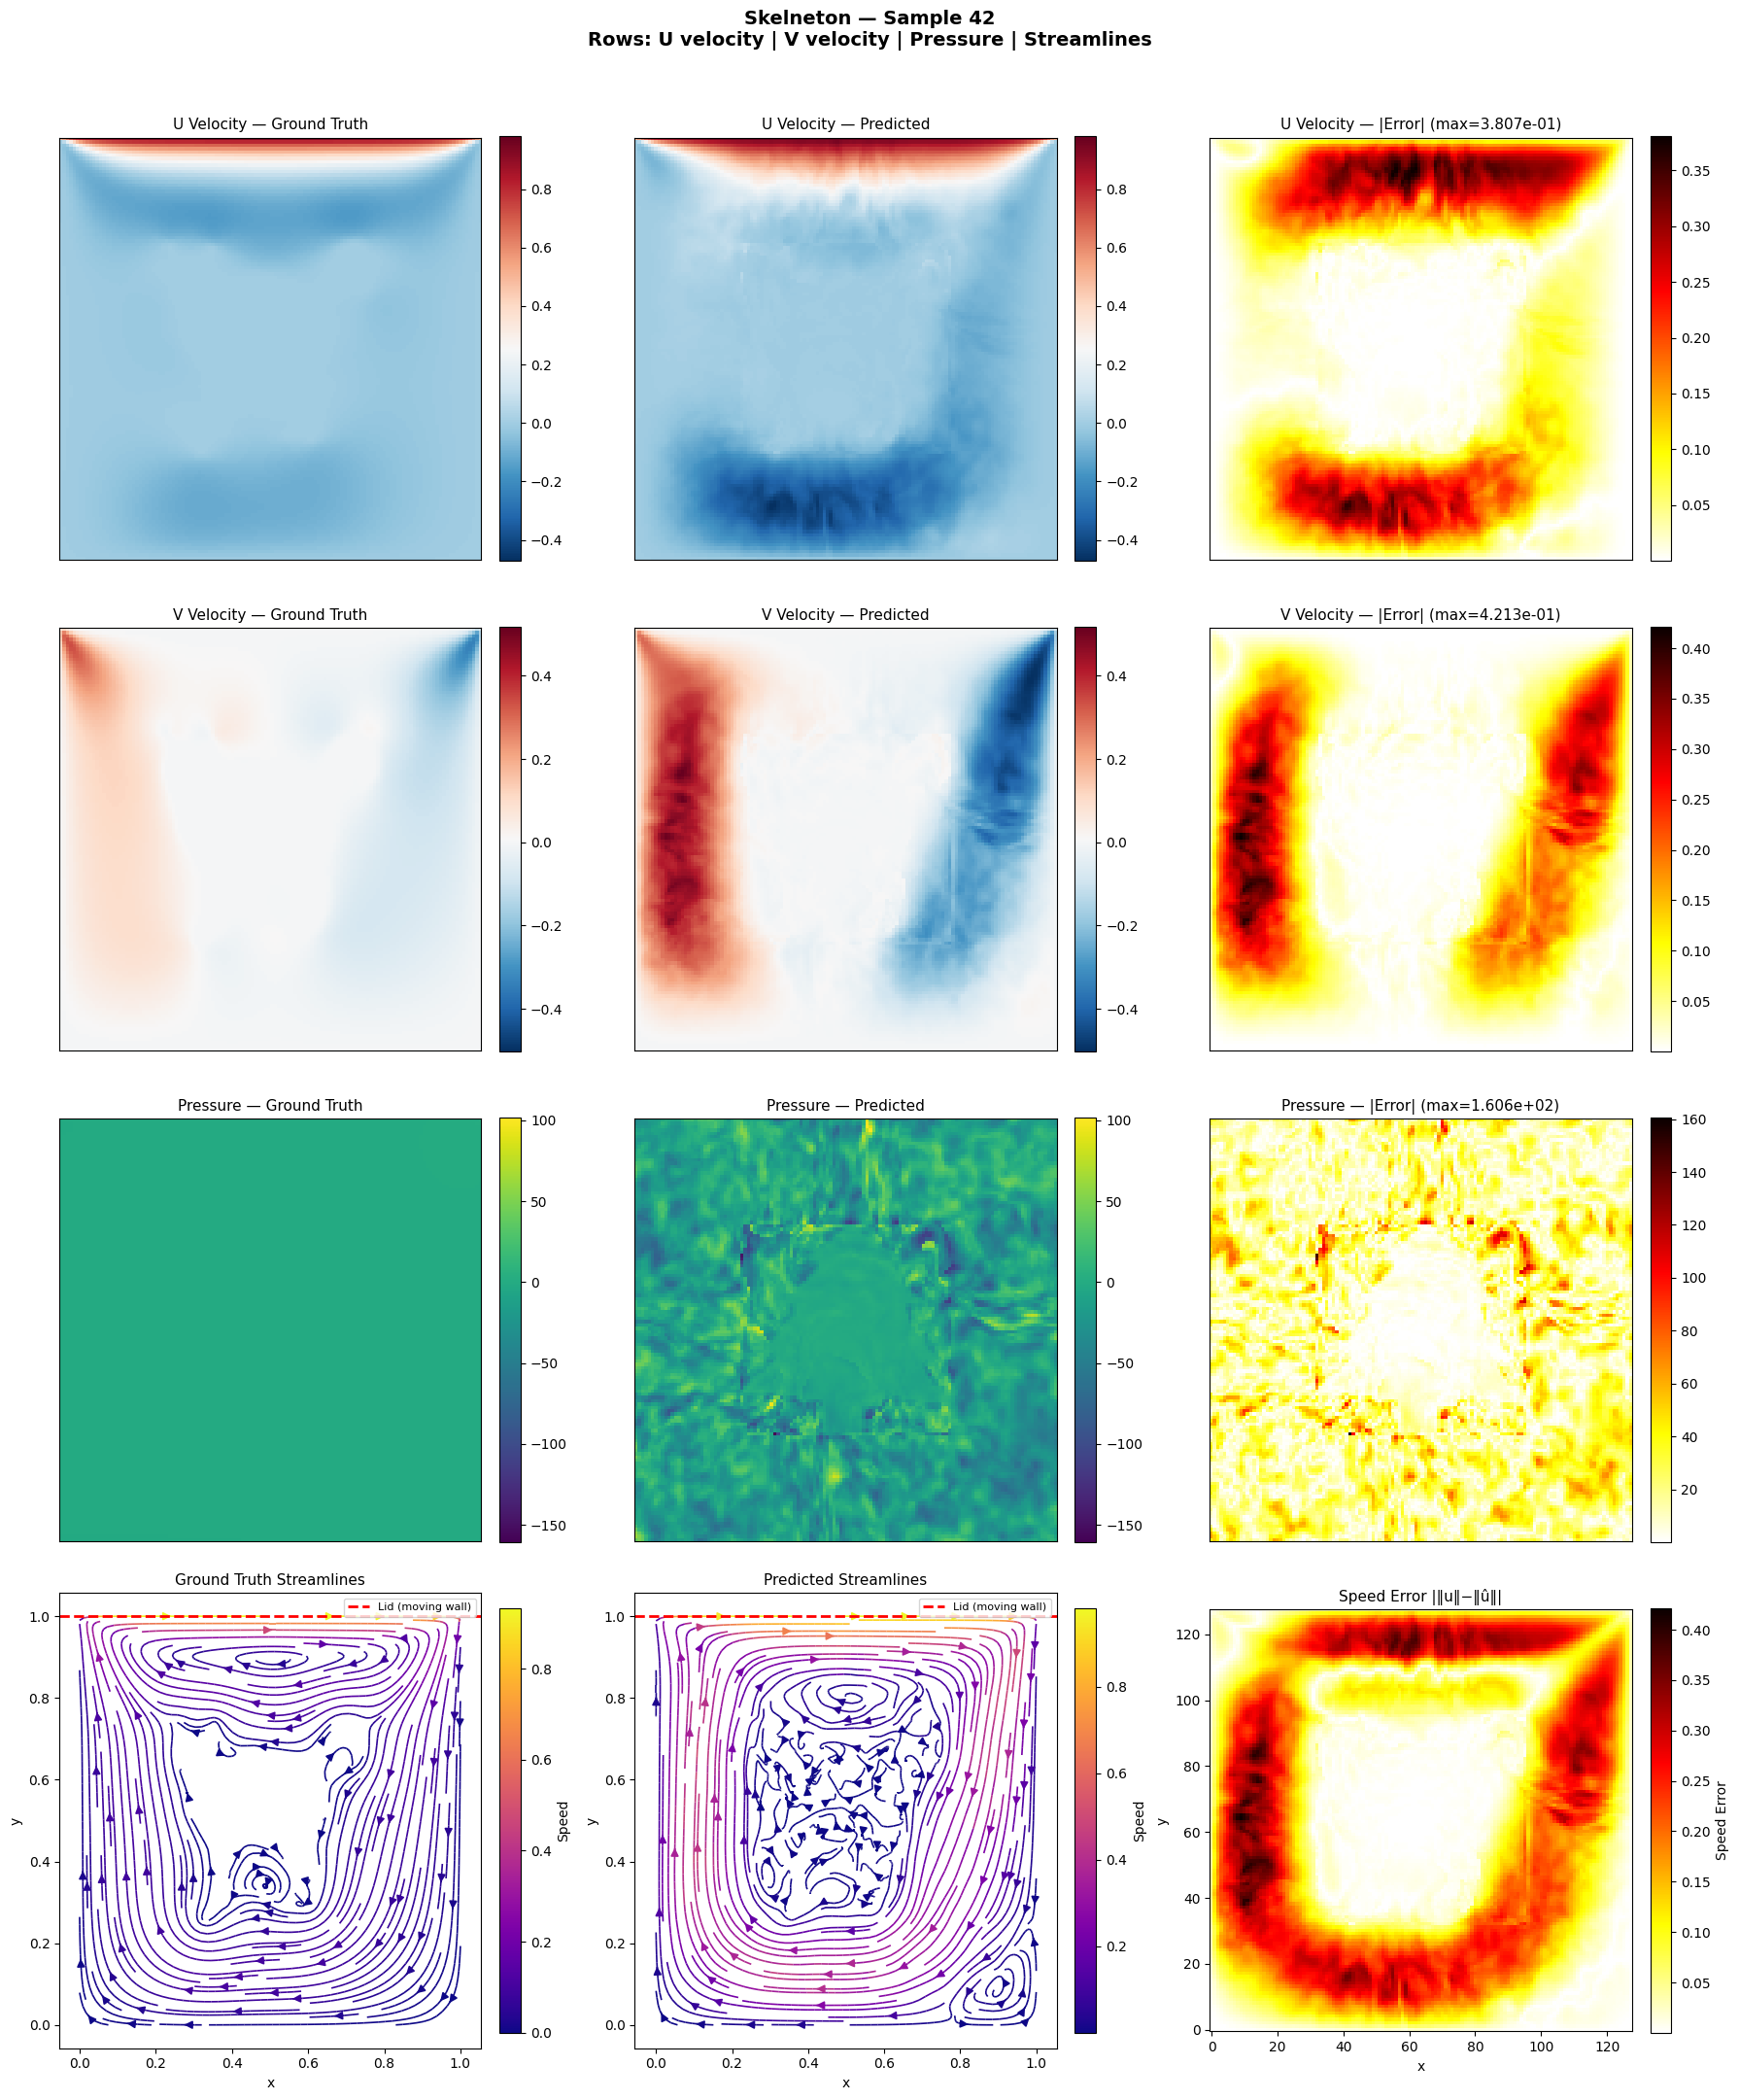

In [ ]:
wandb.login()

for geometry_name, (x_path, y_path) in paths.items():
    # Train and save best checkpoint
    train_geometry(geometry_name, x_path, y_path)

    # Visualize immediately using saved checkpoint
    checkpoint_path = f"/content/drive/MyDrive/LDC_data/{geometry_name}_fno_best.pt"
    run_visualization(geometry_name, x_path, y_path, checkpoint_path, device, num_samples=3)